实证资产定价的“四大剔除原则”

在画图和跑回归之前，文献中通常遵循以下四大黄金剔除原则（主要针对 CRSP 数据库）：

1. 仙股与低价股剔除 (Penny Stock Filter)

原则：剔除每月末收盘价低于 $5（或至少低于 $1）的股票。

原因：这类股票的价格变动受到最小报价单位（Tick Size）的严重影响。比如从 $0.50 涨到 $0.55 就是 10% 的收益。这种离散跳跃会破坏 PIT 理论上所要求的“连续概率分布（Continuous Distribution）”假设。

2. 资产类别剔除 (Share Code Filter)

原则：只保留普通股（Ordinary Common Shares，CRSP 中 shrcd 为 10 或 11）。

原因：必须剔除 ADRs（存托凭证）、REITs（房地产信托）、封闭式基金（Closed-end Funds）和 ETFs。因为它们的尾部风险和收益生成机制与普通实体公司完全不同，混合在一起会污染模型的机制学习。

3. 交易所剔除 (Exchange Code Filter)

原则：只保留在 NYSE, AMEX, 和 NASDAQ 上市的股票（CRSP 中 exchcd 为 1, 2, 3）。

原因：剔除在粉单市场（Pink Sheets）或场外交易（OTC）的股票，这些股票流动性极差，收益率的“肥尾”往往是由于几个月不交易突然复牌暴跌造成的假象。

4. 行业剔除 (Industry Filter - 可选)

原则：剔除金融业（SIC Codes 6000-6999）和公用事业（SIC Codes 4900-4999）。

原因：金融公司的高杠杆是其行业常态，而非财务困境；公用事业的收益率受到严格的政府管制，缺乏自由市场的尾部波动。不过，如果你研究的正是全市场的系统性尾部风险，金融股有时也会被保留，这取决于你的具体研究设计。

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import json
import torch
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.dates as mdates
import math
import os
import statsmodels.api as sm
from scipy import stats
from scipy.stats.mstats import winsorize
from statsmodels.stats.sandwich_covariance import cov_hac
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from adjustText import adjust_text
from matplotlib.lines import Line2D
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)  # 显示所有列
pd.set_option('display.max_rows', 100)     # 显示前100行

os.chdir('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/code')

In [2]:
timestamp = '20260726_1943'

final_oos_df = pd.read_parquet(f'/Users/jianbinchen/Downloads/final_oos_df_{timestamp}.parquet')
metrics_df=pd.read_parquet(f'/Users/jianbinchen/Downloads/metrics_df_{timestamp}.parquet')
industry_embeddings = pd.read_parquet(f'/Users/jianbinchen/Downloads/industry_embeddings_50x6_{timestamp}.parquet')

micro_df = pd.read_parquet('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/data/micro_data.parquet') # local 路径
macro_df = pd.read_parquet('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/data/MacroFactor_McCracken.parquet')  # local 路径

ffi49_pairs = pd.read_parquet('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/data/comp_wrds_ratios.parquet', engine='pyarrow', 
                                   columns=['ffi49', 'ffi49_desc']).drop_duplicates()

# print all examples of first 3 row and last 3 row of all dataframes
print("final_oos_df:")
display(pd.concat([final_oos_df.head(3), final_oos_df.tail(3)]))

print("metrics_df:")
display(pd.concat([metrics_df.head(3), metrics_df.tail(3)]))

print("industry_embeddings:")
display(pd.concat([industry_embeddings.head(3), industry_embeddings.tail(3)]))

print("micro_df:")
display(pd.concat([micro_df.head(3), micro_df.tail(3)]))

print("macro_df:")
display(pd.concat([macro_df.head(3), macro_df.tail(3)]))

print("ffi49_pairs:")
display(pd.concat([ffi49_pairs.head(3), ffi49_pairs.tail(3)]))

final_oos_df:


,permno,mthcaldt,target_ret_final,model_id,pi_vec,pi_logits_vec,mu_vec,sigma_vec,nu_vec
0,10001,2007-01-31,0.264774,mdn_t_k3,"[0.2643515169620514, 0.17685873806476593, 0.55...","[-0.3689113259315491, -0.7708395719528198, 0.3...","[-0.047872625291347504, 0.09804233908653259, -...","[0.06691180169582367, 0.1300002932548523, 0.05...","[5.00151252746582, 3.828868865966797, 7.246811..."
1,10002,2007-01-31,0.033054,mdn_t_k3,"[0.2643515169620514, 0.17685873806476593, 0.55...","[-0.3689113259315491, -0.7708395719528198, 0.3...","[-0.027500763535499573, 0.09503047168254852, 0...","[0.05739731341600418, 0.07363724708557129, 0.0...","[5.095623016357422, 4.1786041259765625, 7.4813..."
2,10025,2007-01-31,-0.028094,mdn_t_k3,"[0.2643515169620514, 0.17685873806476593, 0.55...","[-0.3689113259315491, -0.7708395719528198, 0.3...","[-0.08417905867099762, 0.13530036807060242, 0....","[0.08642611652612686, 0.11595416069030762, 0.0...","[5.409781455993652, 4.2860002517700195, 7.3344..."
683376,93426,2024-12-31,-0.007243,mdn_t_k3,"[0.0963088646531105, 0.050281938165426254, 0.8...","[-0.44140464067459106, -1.09131920337677, 1.74...","[-0.07274364680051804, 0.08781096339225769, 0....","[0.06513174623250961, 0.09181874990463257, 0.0...","[6.069814682006836, 3.3891680240631104, 3.8323..."
683377,93434,2024-12-31,0.147685,mdn_t_k3,"[0.0963088646531105, 0.050281938165426254, 0.8...","[-0.44140464067459106, -1.09131920337677, 1.74...","[-0.11989042907953262, 0.050070442259311676, -...","[0.1767282783985138, 0.3059892952442169, 0.140...","[5.33336877822876, 3.3237223625183105, 2.17696..."
683378,93436,2024-12-31,0.001882,mdn_t_k3,"[0.0963088646531105, 0.050281938165426254, 0.8...","[-0.44140464067459106, -1.09131920337677, 1.74...","[-0.12016196548938751, 0.10361357033252716, -0...","[0.09206998348236084, 0.09887731075286865, 0.0...","[8.304093360900879, 4.867342472076416, 6.51540..."


metrics_df:


,window,train_period,test_period,duration_sec,best_val_loss,epochs_run,train_loss_trace,val_loss_trace
0,0,1991-01 to 2005-12,2007-01 to 2007-12,114.243161,-1.020003,22,"[-0.7895895325796961, -0.8303014727370716, -0....","[-0.9755707532068811, -1.0200028522627957, -1...."
1,1,1992-01 to 2006-12,2008-01 to 2008-12,112.452091,-0.870570,23,"[-0.85295050520172, -0.8568775718191783, -0.85...","[-0.864853351164184, -0.8680113880079069, -0.8..."
2,2,1993-01 to 2007-12,2009-01 to 2009-12,140.722479,-0.226304,29,"[-0.8608787323692193, -0.8643227088316977, -0....","[-0.22139779558698303, -0.2215726593696101, -0..."
15,15,2006-01 to 2020-12,2022-01 to 2022-12,81.748896,-0.783496,24,"[-1.0049373717052408, -1.0143958408292275, -1....","[-0.7786342168185328, -0.7828648765847588, -0...."
16,16,2007-01 to 2021-12,2023-01 to 2023-12,140.442799,-0.666503,41,"[-1.0004552418737205, -1.0032894875253204, -1....","[-0.6363558538603211, -0.6427539547198662, -0...."
17,17,2008-01 to 2022-12,2024-01 to 2024-12,162.608436,-0.645178,49,"[-1.0048820328747217, -1.0110494009395203, -1....","[-0.6234126339516437, -0.6150078851234935, -0...."


industry_embeddings:


...

,permno,mthcaldt,mthret,mthprc,mthcap,siccd,gvkey,bm,evm,pe_exi,ps,pcf,pfcf,npm,opmad,gpm,cfm,roe,aftret_invcapx,gprof,debt_at,debt_ebitda,short_debt,ocf_lct,de_ratio,cash_ratio,curr_ratio,at_turn,rect_turn,pay_turn,sale_equity,rd_sale,adv_sale,staff_sale,accrual,ffi49,target_ret_final,MOM12m,mu_bench,sigma_bench,mthcap_log
0,10001,1991-01-31,0.013158,9.625,1.014475e+04,4920.0,012994,0.896385,5.690808,3.307560,0.445982,4.872598,14.070388,0.044401,0.099749,0.138304,0.082956,0.112235,0.112708,0.161306,0.392076,2.430626,0.061202,0.672101,1.796365,0.316439,1.340247,1.166318,8.789413,10.931698,3.261452,0.000000,0.0,0.0,-0.055775,31,0.012987,0.009425,0.002110,0.022682,9.224712
1,10001,1991-02-28,0.012987,9.750,1.027650e+04,4920.0,012994,0.975332,5.299653,3.037383,0.434947,5.205927,14.253121,0.047361,0.103356,0.141152,0.085157,0.121406,0.116860,0.168351,0.378677,2.249325,0.050190,0.614188,1.755852,0.289359,1.348320,1.192696,8.491285,10.618904,3.286892,0.000000,0.0,0.0,-0.042869,31,-0.012244,0.029179,0.003717,0.022716,9.237615
2,10001,1991-03-31,-0.012244,9.500,1.001300e+04,4920.0,012994,0.975332,5.299653,2.959502,0.423795,5.072442,13.887656,0.047361,0.103356,0.141152,0.085157,0.121406,0.116860,0.168351,0.378677,2.249325,0.050190,0.614188,1.755852,0.289359,1.348320,1.192696,8.491285,10.618904,3.286892,0.000000,0.0,0.0,-0.042869,31,0.039474,0.029348,0.001628,0.022954,9.211640
1560357,93436,2024-10-31,-0.045025,249.850,8.020335e+08,3711.0,184996,0.105166,57.713252,69.210526,8.406271,69.482219,369.690039,0.131885,0.075809,0.229558,0.183071,0.217032,0.200551,0.207100,0.095088,0.822338,0.293684,0.409772,0.696792,1.017029,1.760274,0.902169,26.475384,5.220111,1.543949,0.047001,0.0,0.0,0.010123,23,0.381469,0.302679,0.027542,0.140071,20.502661
1560358,93436,2024-11-30,0.381469,345.160,1.107984e+09,3711.0,184996,0.083346,53.762150,93.286486,11.394010,76.450592,306.628288,0.132692,0.084756,0.234822,0.183922,0.208738,0.190668,0.203448,0.099842,0.839369,0.274887,0.497103,0.690047,1.047903,1.798235,0.866390,25.589359,5.285830,1.475261,0.044858,0.0,0.0,-0.014637,23,0.170008,0.040696,0.043050,0.167882,20.825808
1560359,93436,2024-12-31,0.170008,403.840,1.298958e+09,3711.0,184996,0.083346,53.762150,109.145946,13.368497,89.698836,274.076290,0.132692,0.084756,0.234822,0.183922,0.208738,0.190668,0.203448,0.099842,0.839369,0.274887,0.497103,0.690047,1.047903,1.798235,0.866390,25.589359,5.285830,1.475261,0.044858,0.0,0.0,-0.014637,23,0.001882,0.389088,0.054301,0.171772,20.984828


macro_df:


,mthcaldt,PAYEMS,UNRATE,CLAIMSx,INDPRO,DPCERA3M086SBEA,AMDMNOx,ISRATIOx,HOUST,M2SL,NONBORRES,BUSLOANS,FEDFUNDS,CP3Mx,UEMPMEAN,CPIAUCSL,VIXCLSx,BAAFFM,TERM_SPREAD,CREDIT_SPREAD
0,1991-01-31,-0.001000,0.1,0.023836,-0.005920,-0.000778,0.040338,0.02,6.876265,0.001402,-0.069067,0.000930,-0.50,-0.11,0.1,0.001485,22.5845,3.12,1.34,2.35
1,1991-02-28,-0.001892,0.1,-0.041536,-0.004931,-0.003955,-0.029746,0.02,6.682109,0.001999,-0.093898,-0.007471,-0.40,-0.70,-0.3,-0.000014,26.9318,3.54,1.87,2.36
2,1991-03-31,-0.002384,0.2,0.091651,-0.007933,-0.009491,0.005330,0.02,6.872128,0.000704,0.100378,0.005295,-0.66,-0.61,0.5,-0.002975,22.1126,3.82,1.91,2.22
405,2024-10-31,0.001598,-0.1,-0.029656,-0.002832,0.003543,-0.007867,0.01,7.210818,-0.001050,-0.031354,0.002598,-0.20,-0.26,1.6,-0.000073,17.6597,0.29,-1.00,1.70
406,2024-11-30,0.000075,0.0,0.055299,-0.002629,0.001225,0.002425,0.00,7.178545,0.000319,0.023649,-0.000157,-0.30,-0.24,0.3,0.000641,19.9478,0.80,-0.41,1.53
407,2024-12-31,0.001426,0.1,-0.078988,-0.001472,0.002754,-0.010575,0.00,7.161622,0.002139,0.024533,-0.002535,-0.19,-0.09,0.8,0.000686,15.9822,1.13,-0.06,1.42


ffi49_pairs:


,ffi49,ffi49_desc
0,43.0,RTAIL
1,48.0,FIN
3,46.0,INSUR
949,40.0,BOXES
1106,3.0,SODA
1162,25.0,SHIPS


In [3]:
# ES_df = pd.read_parquet(f'/Users/jianbinchen/Downloads/ES_df_{timestamp}.parquet') 
ES_df = pd.read_parquet('/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN/output/ES_df_20260726_1619.parquet')
display(pd.concat([ES_df.head(3), ES_df.tail(3)]))

,permno,mthcaldt,es_1,var_1,es_5,var_5,es_10,var_10,mean_pred,vol_pred,realized_ret
0,10001,2007-01-31,0.361933,-0.245594,0.213810,-0.140835,0.166785,-0.103217,0.004135,0.111934,0.264774
1,10002,2007-01-31,0.229765,-0.169163,0.144511,-0.097262,0.112688,-0.067777,0.017404,0.078709,0.033054
2,10025,2007-01-31,0.379688,-0.292127,0.254742,-0.183926,0.206301,-0.136662,0.008536,0.127882,-0.028094
683376,93426,2024-12-31,0.325873,-0.234464,0.203317,-0.138572,0.160297,-0.100294,0.001323,0.092883,-0.007243
683377,93434,2024-12-31,1.623925,-0.904318,0.794725,-0.437481,0.578162,-0.304866,-0.032410,0.475004,0.147685
683378,93436,2024-12-31,0.392429,-0.316582,0.277259,-0.208047,0.229011,-0.158497,-0.008170,0.123914,0.001882


In [4]:
wrds_path = '/Users/jianbinchen/NonSync/GitHub/Research/DataSet/WRDS.sqlite'
# merge crsp_wrds_msfv2_query_1990 and comp_wrds_ratios by ccm link
with sqlite3.connect(wrds_path) as db_conn:
    crsp_msenames = pd.read_sql('SELECT * FROM crsp_msenames', db_conn)
display(pd.concat([crsp_msenames.head(3), crsp_msenames.tail(3)]))

,permno,namedt,nameendt,shrcd,exchcd,siccd,ncusip,ticker,comnam,shrcls,tsymbol,naics,primexch,trdstat,secstat,permco,compno,issuno,hexcd,hsiccd,cusip
0,10000,1986-01-07,1986-12-03,10,3,3990,68391610,OMFGA,OPTIMUM MANUFACTURING INC,A,OMFGA,None,Q,A,R,7952,60007905,10396,3,3990,68391610
1,10000,1986-12-04,1987-03-09,10,3,3990,68391610,OMFGA,OPTIMUM MANUFACTURING INC,A,OMFAC,None,Q,A,R,7952,60007905,10396,3,3990,68391610
2,10000,1987-03-10,1987-06-11,10,3,3990,68391610,OMFGA,OPTIMUM MANUFACTURING INC,A,OMFGA,None,Q,A,R,7952,60007905,10396,3,3990,68391610
117827,93436,2017-02-02,2023-04-02,11,3,9999,88160R10,TSLA,TESLA INC,None,TSLA,336111,Q,A,R,53453,60069832,66252,3,9999,88160R10
117828,93436,2023-04-03,2024-06-19,11,3,9999,88160R10,TSLA,TESLA INC,None,TSLA,336110,Q,A,R,53453,60069832,66252,3,9999,88160R10
117829,93436,2024-06-20,2024-12-31,11,3,9999,88160R10,TSLA,TESLA INC,None,TSLA,336110,Q,A,R,53453,60069832,66252,3,9999,88160R10


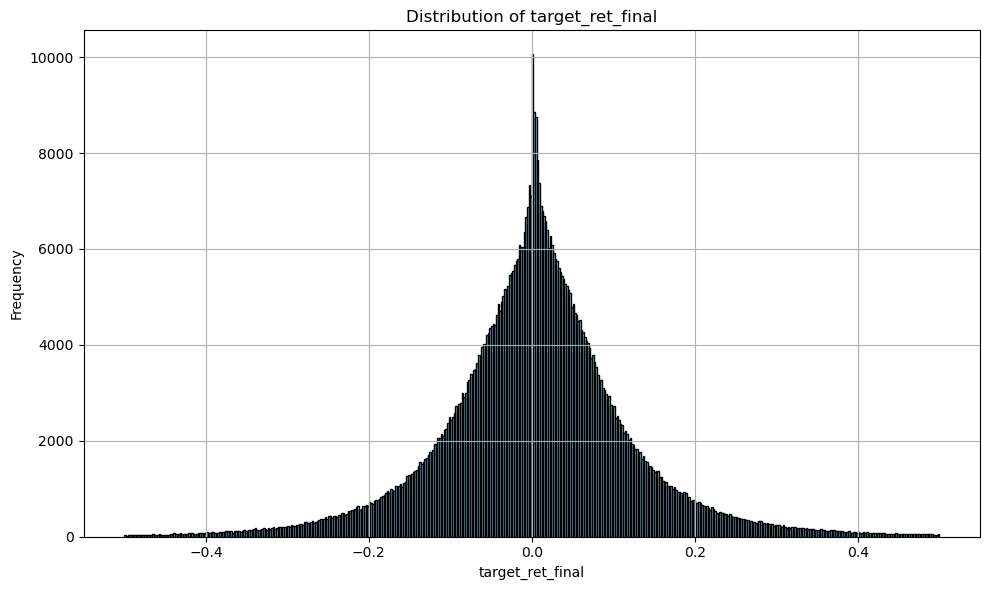

In [5]:
plt.figure(figsize=(10, 6))
plt.hist(final_oos_df['target_ret_final'], bins=500, range=(-0.5, 0.5), color='skyblue', edgecolor='black')
plt.title('Distribution of target_ret_final')
plt.xlabel('target_ret_final')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()  

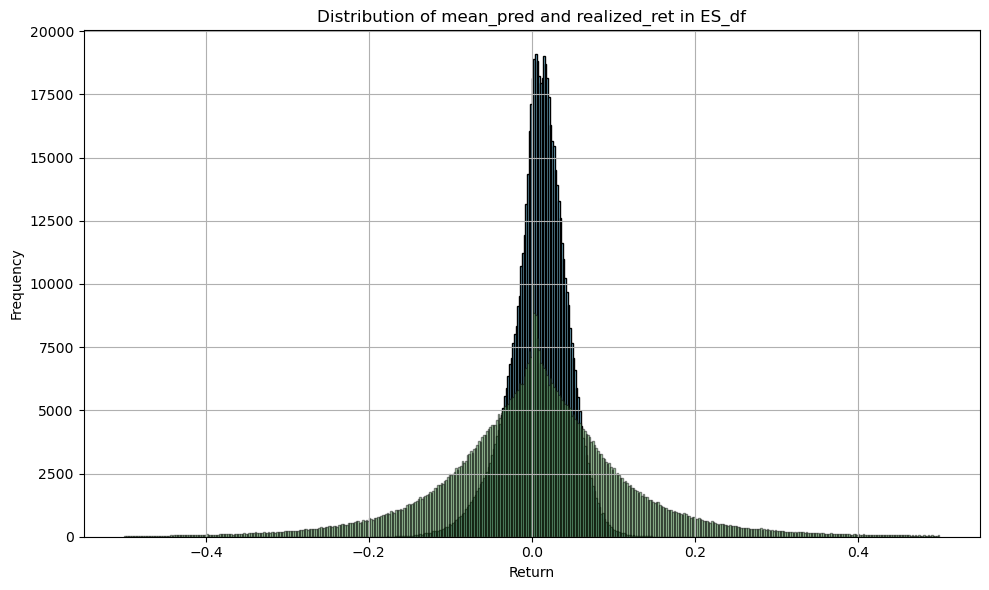

count    683379.000000
mean          0.008305
std           0.035239
min          -0.205680
25%          -0.010060
50%           0.010504
75%           0.030583
max           0.182507
Name: mean_pred, dtype: float64

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(ES_df['mean_pred'], bins=500, range=(-0.5, 0.5), color='skyblue', edgecolor='black')
plt.hist(ES_df['realized_ret'], bins=500, range=(-0.5, 0.5), color='lightgreen', edgecolor='black', alpha=0.5)
plt.title('Distribution of mean_pred and realized_ret in ES_df')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()
ES_df['mean_pred'].describe()

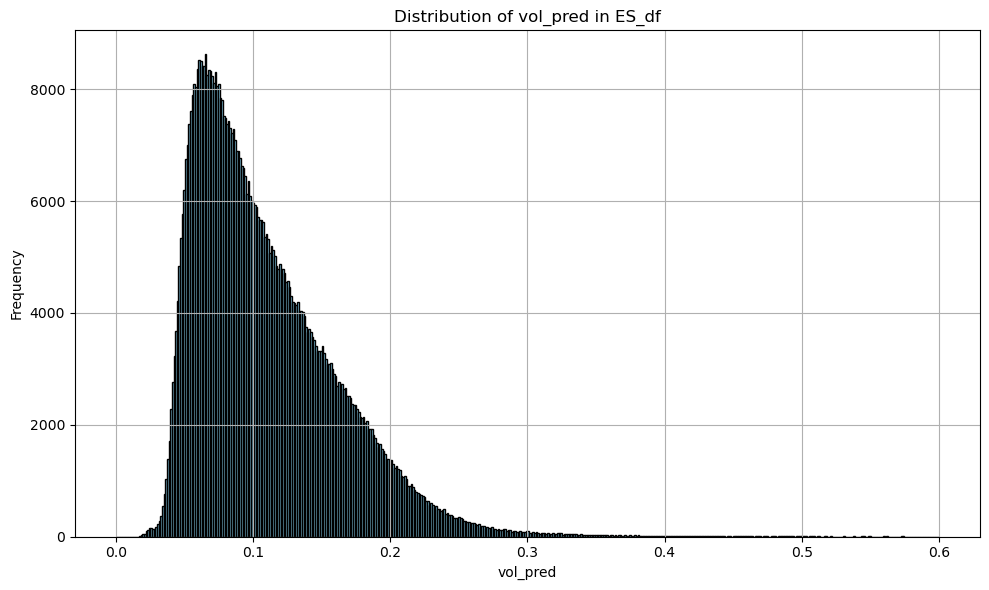

count    683379.000000
mean          0.109182
std           0.052377
min           0.016746
25%           0.069101
50%           0.097110
75%           0.138586
max           0.925834
Name: vol_pred, dtype: float64

In [7]:
# draw the distribution of vol_pred in ES_df
plt.figure(figsize=(10, 6))
plt.hist(ES_df['vol_pred'], bins=500, range=(0, 0.6), color='skyblue', edgecolor='black')
plt.title('Distribution of vol_pred in ES_df')
plt.xlabel('vol_pred')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()
ES_df['vol_pred'].describe()

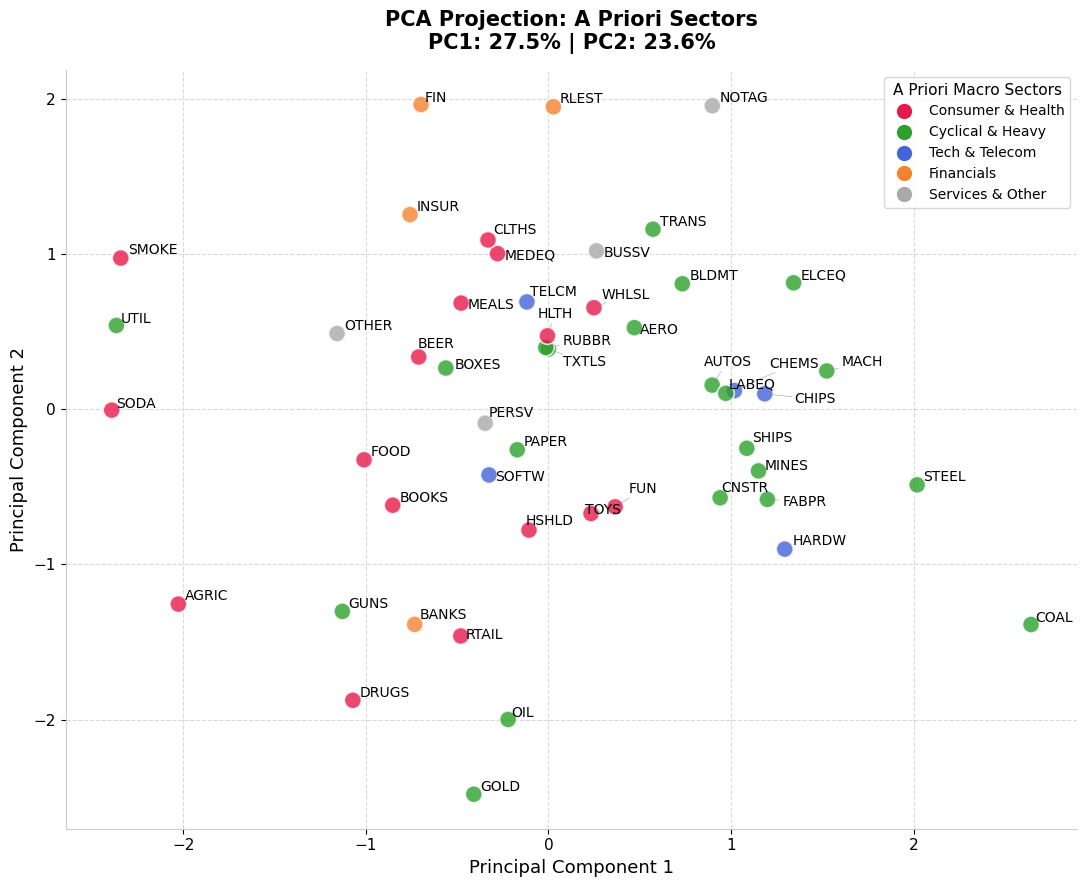

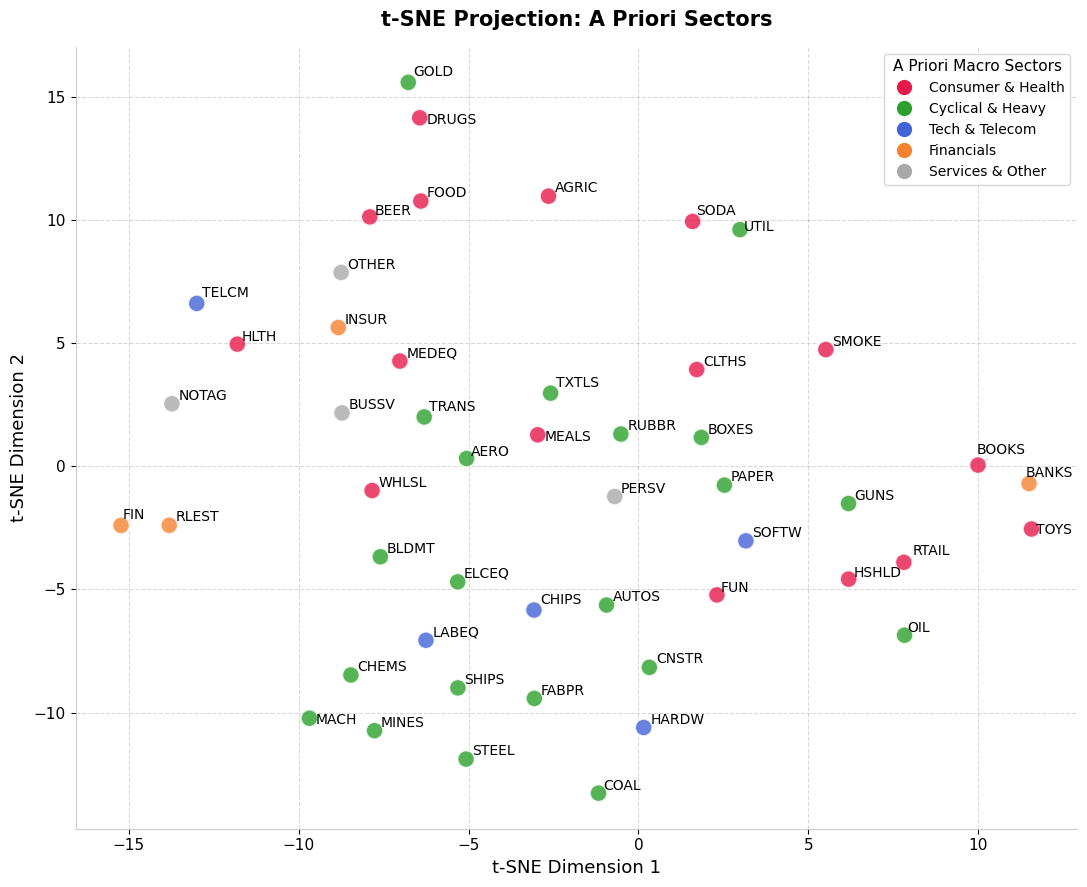

In [8]:
ffi49_pairs['ffi49']=ffi49_pairs['ffi49'].fillna(0).astype(int)
ffi49_pairs["ffi49_desc"] = ffi49_pairs["ffi49_desc"].replace([None, np.nan], "NOTAG")

df_emb=pd.merge(ffi49_pairs, industry_embeddings, on='ffi49', how='left')

# 1. 提取 6 维特征
features = [f'emb_dim_{i+1}' for i in range(6)]
X = df_emb[features].values
labels = df_emb['ffi49_desc'].values

# 2. 降维计算 (同时准备好 PCA 和 t-SNE 的坐标)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
var_ratio = pca.explained_variance_ratio_

tsne = TSNE(n_components=2, perplexity=12, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X)

# 3. 完美的先验映射字典 (已修复 SOFTW, HARDW 并在代码中处理 None)
macro_sector_mapping = {
    'AGRIC': 'Consumer & Health', 'FOOD': 'Consumer & Health', 'SODA': 'Consumer & Health', 
    'BEER': 'Consumer & Health', 'SMOKE': 'Consumer & Health', 'TOYS': 'Consumer & Health', 
    'FUN': 'Consumer & Health', 'BOOKS': 'Consumer & Health', 'HSHLD': 'Consumer & Health', 
    'CLTHS': 'Consumer & Health', 'HLTH': 'Consumer & Health', 'MEDEQ': 'Consumer & Health', 
    'DRUGS': 'Consumer & Health', 'WHLSL': 'Consumer & Health', 'RTAIL': 'Consumer & Health', 
    'MEALS': 'Consumer & Health',
    
    'CHEMS': 'Cyclical & Heavy', 'RUBBR': 'Cyclical & Heavy', 'TXTLS': 'Cyclical & Heavy', 
    'BLDMT': 'Cyclical & Heavy', 'CNSTR': 'Cyclical & Heavy', 'STEEL': 'Cyclical & Heavy', 
    'FABPR': 'Cyclical & Heavy', 'MACH': 'Cyclical & Heavy', 'AUTOS': 'Cyclical & Heavy', 
    'AERO': 'Cyclical & Heavy', 'SHIPS': 'Cyclical & Heavy', 'GUNS': 'Cyclical & Heavy', 
    'GOLD': 'Cyclical & Heavy', 'MINES': 'Cyclical & Heavy', 'COAL': 'Cyclical & Heavy', 
    'OIL': 'Cyclical & Heavy', 'TRANS': 'Cyclical & Heavy', 'PAPER': 'Cyclical & Heavy', 
    'BOXES': 'Cyclical & Heavy', 'UTIL': 'Cyclical & Heavy', 'ELCEQ': 'Cyclical & Heavy', # 修正
    
    'TELCM': 'Tech & Telecom', 'HARDW': 'Tech & Telecom', 'SOFTW': 'Tech & Telecom', 
    'CHIPS': 'Tech & Telecom', 'LABEQ': 'Tech & Telecom', 
    
    'BANKS': 'Financials', 'INSUR': 'Financials', 'RLEST': 'Financials', 'FIN': 'Financials',
    
    'PERSV': 'Services & Other', 'BUSSV': 'Services & Other', 'OTHER': 'Services & Other', 
    'NOTAG': 'Services & Other'
}

# 映射颜色并使用 fillna 兜底处理任何未匹配的脏数据
df_emb['Macro_Sector'] = df_emb['ffi49_desc'].map(macro_sector_mapping).fillna('Services & Other')

sector_colors = {
    'Consumer & Health': '#e6194B', # 红色
    'Cyclical & Heavy': '#2ca02c',  # 绿色
    'Tech & Telecom': '#4363d8',    # 蓝色
    'Financials': '#f58231',        # 橙色
    'Services & Other': '#a9a9a9'   # 灰色
}
point_colors = df_emb['Macro_Sector'].map(sector_colors).tolist()

# 统一制作漂亮的图例
legend_elements = [Line2D([0], [0], marker='o', color='w', label=sector, 
                          markerfacecolor=color, markersize=12)
                   for sector, color in sector_colors.items()]

plt.rcParams.update({'font.size': 11})

# ========================================================
# 独立图 1：PCA 投影图 (带先验颜色)
# ========================================================
fig1 = plt.figure(figsize=(11, 9), facecolor='white')
ax1 = plt.gca()
ax1.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.8, s=150, c=point_colors, edgecolors='white', linewidth=1.2)

# 添加带避让算法的文字
texts_pca = [ax1.text(X_pca[i, 0], X_pca[i, 1], labels[i], fontsize=10, fontweight='500') for i in range(len(labels))]
adjust_text(texts_pca, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5, alpha=0.6))

# 图例与美化
ax1.legend(handles=legend_elements, title="A Priori Macro Sectors", loc='best', fontsize=10, title_fontsize=11, frameon=True)
ax1.set_title(f'PCA Projection: A Priori Sectors\nPC1: {var_ratio[0]*100:.1f}% | PC2: {var_ratio[1]*100:.1f}%', fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel('Principal Component 1', fontsize=13)
ax1.set_ylabel('Principal Component 2', fontsize=13)

ax1.set_axisbelow(True)
ax1.grid(True, linestyle='--', color='gray', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#cccccc')
ax1.spines['bottom'].set_color('#cccccc')

plt.tight_layout()
plt.savefig('../paper/fig/Industry_Embedding_PCA.pdf', format='pdf', bbox_inches='tight')
plt.show()


# ========================================================
# 独立图 2：t-SNE 拓扑图 (带先验颜色)
# ========================================================
fig2 = plt.figure(figsize=(11, 9), facecolor='white')
ax2 = plt.gca()
ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.8, s=150, c=point_colors, edgecolors='white', linewidth=1.2)

# 添加带避让算法的文字
texts_tsne = [ax2.text(X_tsne[i, 0], X_tsne[i, 1], labels[i], fontsize=10, fontweight='500') for i in range(len(labels))]
adjust_text(texts_tsne, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5, alpha=0.6))

# 图例与美化
ax2.legend(handles=legend_elements, title="A Priori Macro Sectors", loc='best', fontsize=10, title_fontsize=11, frameon=True)
ax2.set_title('t-SNE Projection: A Priori Sectors', fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel('t-SNE Dimension 1', fontsize=13)
ax2.set_ylabel('t-SNE Dimension 2', fontsize=13)

ax2.set_axisbelow(True)
ax2.grid(True, linestyle='--', color='gray', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#cccccc')
ax2.spines['bottom'].set_color('#cccccc')

plt.tight_layout()
plt.savefig('../paper/fig/Industry_Embedding_tSNE.pdf', format='pdf', bbox_inches='tight')
plt.show()

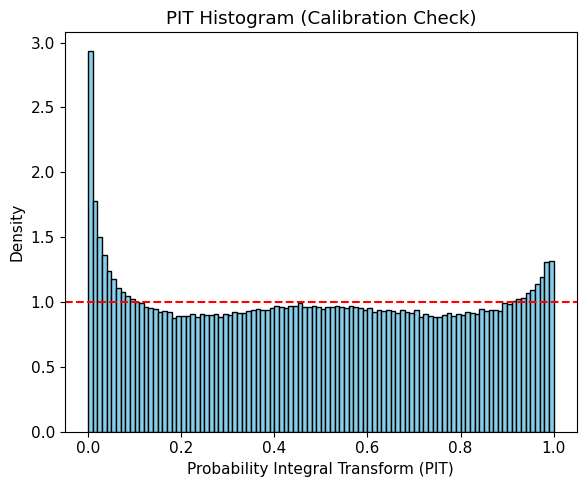

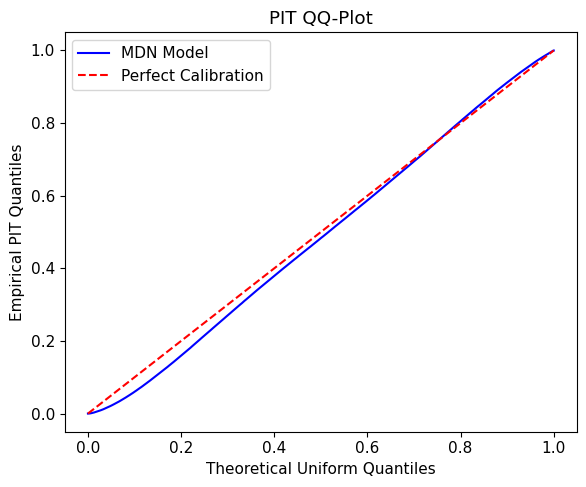

In [24]:
# =================================================================
# 3. 分布校准检验 (PIT Test) - 拆分为独立图表
# =================================================================

# -------------------------
# 图 A: PIT 直方图
# -------------------------
plt.figure(figsize=(6, 5)) # 调整为单图的经典长宽比

plt.hist(ES_df['pit'], bins=100, density=True, color='skyblue', edgecolor='black')

plt.axhline(y=1, color='red', linestyle='--') 
plt.title("PIT Histogram (Calibration Check)")
plt.xlabel("Probability Integral Transform (PIT)")
plt.ylabel("Density")

plt.tight_layout()
# 导出为无损 PDF，bbox_inches='tight' 切除多余白边
plt.savefig('../paper/fig/pit_histogram.pdf', format='pdf', bbox_inches='tight')
plt.show()
plt.close() # 关闭画布，避免内存泄漏和图表重叠


# -------------------------
# 图 B: PIT QQ-Plot（原本就没有使用 seaborn，保持原样即可）
# -------------------------
plt.figure(figsize=(6, 5))
sorted_pit = np.sort(ES_df['pit'])
uniform_dist = np.linspace(0, 1, len(sorted_pit))

plt.plot(uniform_dist, sorted_pit, color='blue', label='MDN Model')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Perfect Calibration')

plt.title("PIT QQ-Plot")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical PIT Quantiles")
plt.legend()

plt.tight_layout()
plt.savefig('../paper/fig/pit_qq_plot.pdf', format='pdf', bbox_inches='tight')
plt.show()
plt.close()

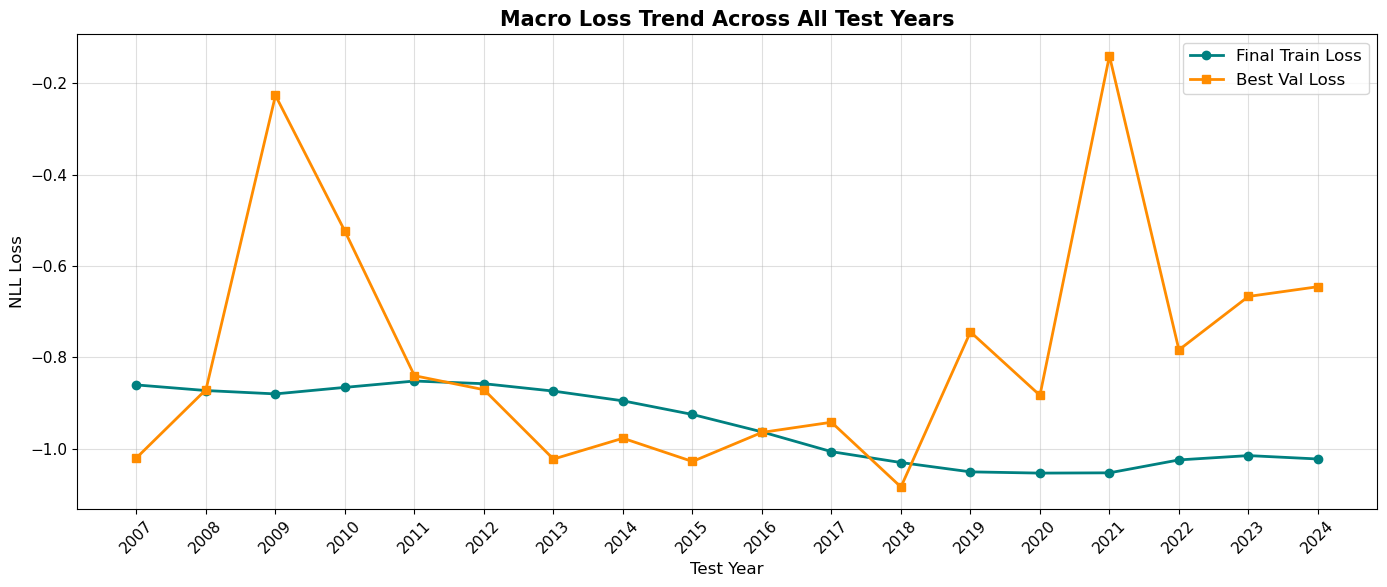

In [9]:
def plot_macro_loss_trend(df):
    plt.figure(figsize=(14, 6))
    
    # 提取每个窗口的最终 Train Loss
    final_train_loss = [trace[-1] for trace in df['train_loss_trace']]
    # 提取验证集最佳 Loss
    best_val_loss = df['best_val_loss'].tolist()
    
    # 提取年份作为 X 轴标签 (假设 test_period 格式为 "2006-01 to 2006-12")
    years = [period.split('-')[0] for period in df['test_period']]
    
    plt.plot(df['window'], final_train_loss, label='Final Train Loss', marker='o', color='teal', linewidth=2)
    plt.plot(df['window'], best_val_loss, label='Best Val Loss', marker='s', color='darkorange', linewidth=2)
    
    plt.xticks(df['window'], years, rotation=45)
    plt.title("Macro Loss Trend Across All Test Years", fontsize=15, fontweight='bold')
    plt.xlabel("Test Year", fontsize=12)
    plt.ylabel("NLL Loss", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

# 运行趋势图
plot_macro_loss_trend(metrics_df)

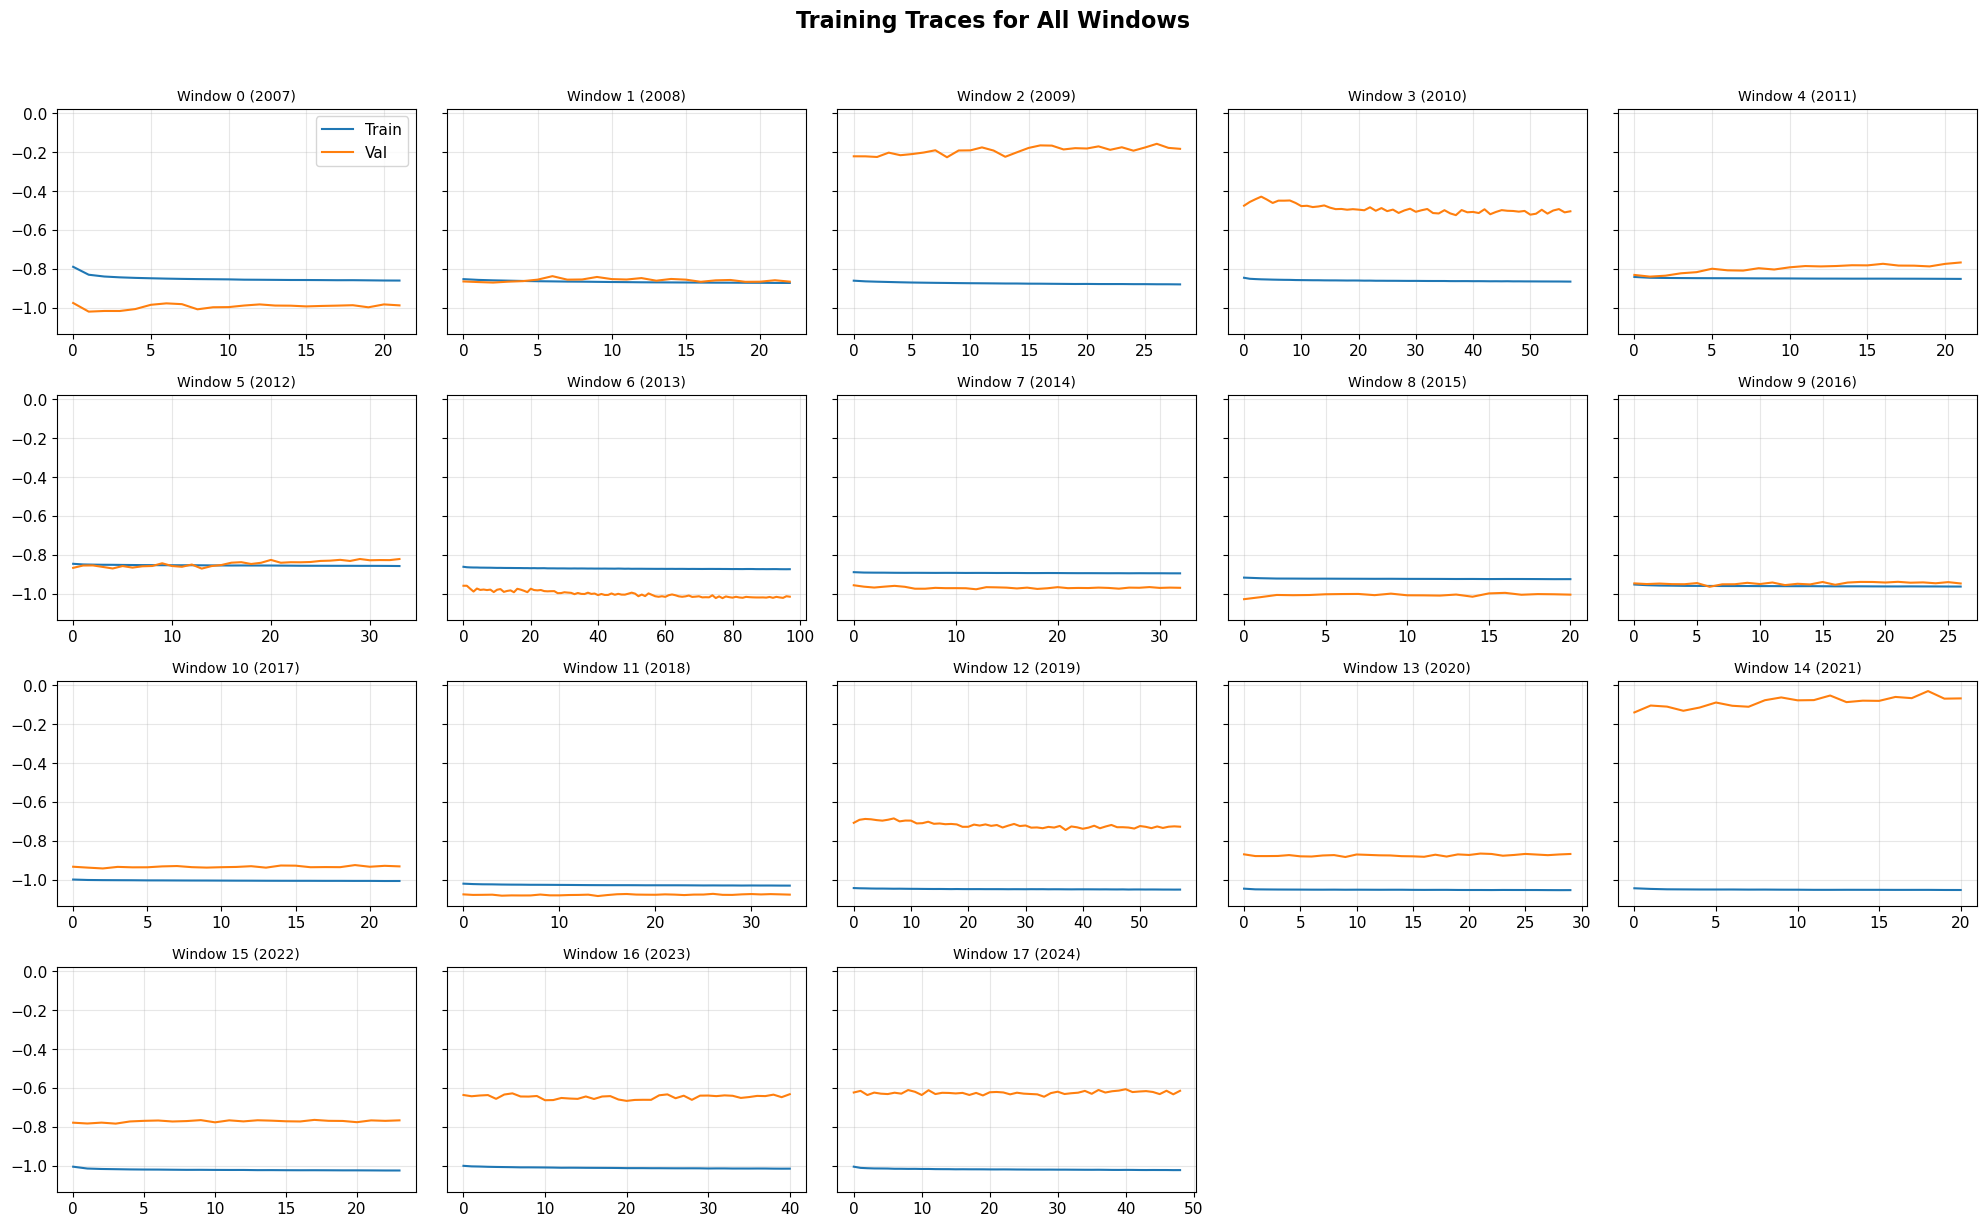

In [10]:
def plot_all_traces_grid(df):
    n_windows = len(df)
    cols = 5  # 每排画 5 个窗口
    rows = math.ceil(n_windows / cols)
    
    # 创建一个巨大的画布
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows), sharex=False, sharey=True)
    axes = axes.flatten()
    
    for idx, row in df.iterrows():
        ax = axes[idx]
        year = row['test_period'].split('-')[0]
        
        ax.plot(row['train_loss_trace'], label='Train')
        ax.plot(row['val_loss_trace'], label='Val')
        ax.set_title(f"Window {row['window']} ({year})", fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # 只在第一个图显示图例，保持画面整洁
        if idx == 0:
            ax.legend()
            
    # 隐藏多余的空白子图
    for i in range(n_windows, len(axes)):
        axes[i].set_visible(False)
        
    plt.suptitle("Training Traces for All Windows", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# 运行展板图
plot_all_traces_grid(metrics_df)

正在分析数据，时间范围: 2007-01-31 到 2024-12-31


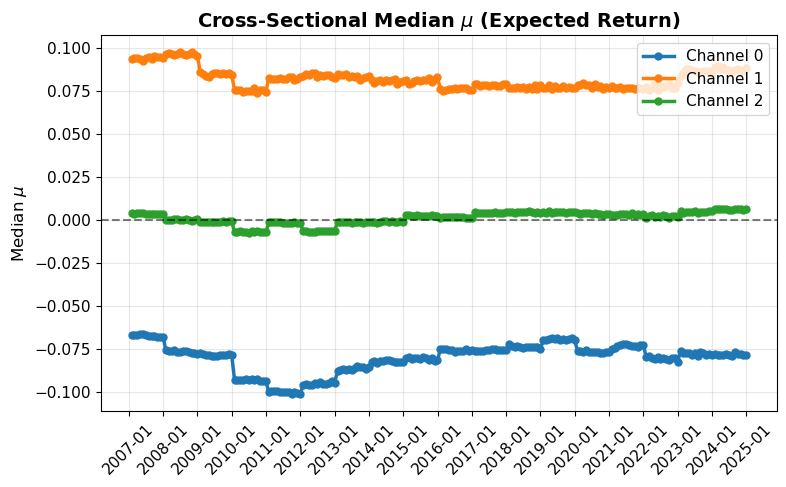

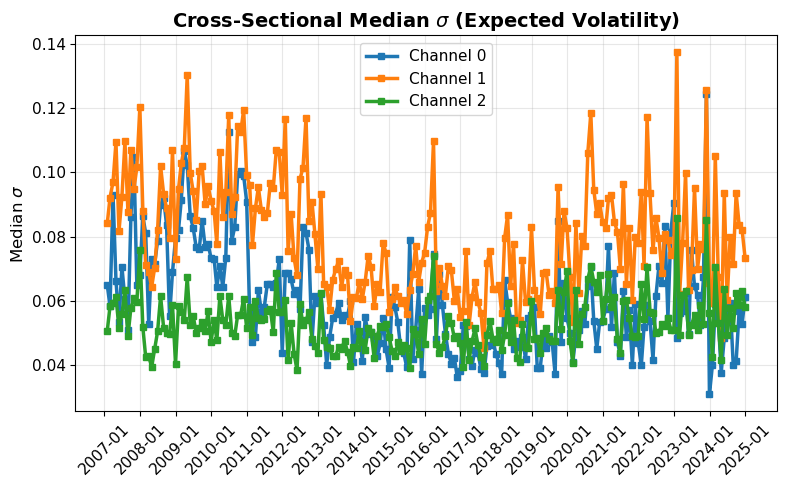

In [11]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_regime_dynamics(df_preds, target_year=None, time_col='mthcaldt'):
    """
    通用函数：绘制指定年份（或全样本）内，每个通道的 mu 和 sigma 演化轨迹
    (已修改为输出两张独立的 PDF 图片以供 LaTeX 排版)
    """
    # 确保图片保存的文件夹存在
    if not os.path.exists('fig'):
        os.makedirs('fig')
        
    df = df_preds.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    
    # 确定文件后缀名
    year_suffix = str(target_year) if target_year is not None else "all"
    
    # 如果指定了年份，则过滤数据
    if target_year is not None:
        df = df[df[time_col].dt.year == target_year]
        if df.empty:
            print(f"警告：未找到 {target_year} 年的数据！")
            return
            
    print(f"正在分析数据，时间范围: {df[time_col].min().date()} 到 {df[time_col].max().date()}")

    # 1. 安全解析 JSON 字符串到 numpy 数组
    if isinstance(df['mu_vec'].iloc[0], str):
        df['mu_arr'] = df['mu_vec'].apply(lambda x: np.array(json.loads(x)))
        df['sigma_arr'] = df['sigma_vec'].apply(lambda x: np.array(json.loads(x)))
    else:
        df['mu_arr'] = df['mu_vec'].apply(np.array)
        df['sigma_arr'] = df['sigma_vec'].apply(np.array)

    num_components = len(df['mu_arr'].iloc[0])
    
    # 2. 定义逐月计算中位数的聚合函数
    def get_monthly_medians(month_df):
        mu_mat = np.vstack(month_df['mu_arr'].values)
        sigma_mat = np.vstack(month_df['sigma_arr'].values)
        
        mu_medians = np.median(mu_mat, axis=0)
        sigma_medians = np.median(sigma_mat, axis=0)
        
        res = {}
        for k in range(num_components):
            res[f'ch{k}_mu'] = mu_medians[k]
            res[f'ch{k}_sigma'] = sigma_medians[k]
        return pd.Series(res)

    # 3. 按月分组并计算
    monthly_stats = df.groupby(time_col).apply(get_monthly_medians).reset_index()
    colors = plt.cm.tab10.colors  

    # ==========================================
    # 图 A：预期收益率 (Mu) 演化
    # ==========================================
    plt.figure(figsize=(8, 5))
    for k in range(num_components):
        plt.plot(monthly_stats[time_col], monthly_stats[f'ch{k}_mu'], 
                 label=f'Channel {k}', color=colors[k], linewidth=2.5, marker='o', markersize=5)
    
    plt.axhline(0, color='black', linestyle='--', alpha=0.5) 
    plt.title(f"Cross-Sectional Median $\mu$ (Expected Return)", fontsize=14, fontweight='bold')
    plt.ylabel("Median $\mu$", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)

    # 优化时间轴
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    if target_year is None:
        ax.xaxis.set_major_locator(mdates.YearLocator(1))
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)

    plt.tight_layout()
    mu_filename = f'../paper/fig/regime_mu_{year_suffix}.pdf'
    plt.savefig(mu_filename, format='pdf', bbox_inches='tight')
    plt.show()
    plt.close()
    # print(f"✅ Mu 演化图已保存为: {mu_filename}")

    # ==========================================
    # 图 B：预期波动率 (Sigma) 演化
    # ==========================================
    plt.figure(figsize=(8, 5))
    for k in range(num_components):
        plt.plot(monthly_stats[time_col], monthly_stats[f'ch{k}_sigma'], 
                 label=f'Channel {k}', color=colors[k], linewidth=2.5, marker='s', markersize=5)
    
    plt.title(f"Cross-Sectional Median $\sigma$ (Expected Volatility)", fontsize=14, fontweight='bold')
    plt.ylabel("Median $\sigma$", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)

    # 优化时间轴
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    if target_year is None:
        ax.xaxis.set_major_locator(mdates.YearLocator(1))
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)

    plt.tight_layout()
    sigma_filename = f'../paper/fig/regime_sigma_{year_suffix}.pdf'
    plt.savefig(sigma_filename, format='pdf', bbox_inches='tight')
    plt.show()
    plt.close()
    # print(f"✅ Sigma 演化图已保存为: {sigma_filename}")

# 运行示例：
plot_regime_dynamics(final_oos_df)

🔧 检测到模型通道数 K = 3
📊 正在按照 MEDIAN of MU 进行横截面动态重排序...
✅ 图表已保存至 ../paper/fig/macro_regime_nber_mu.pdf


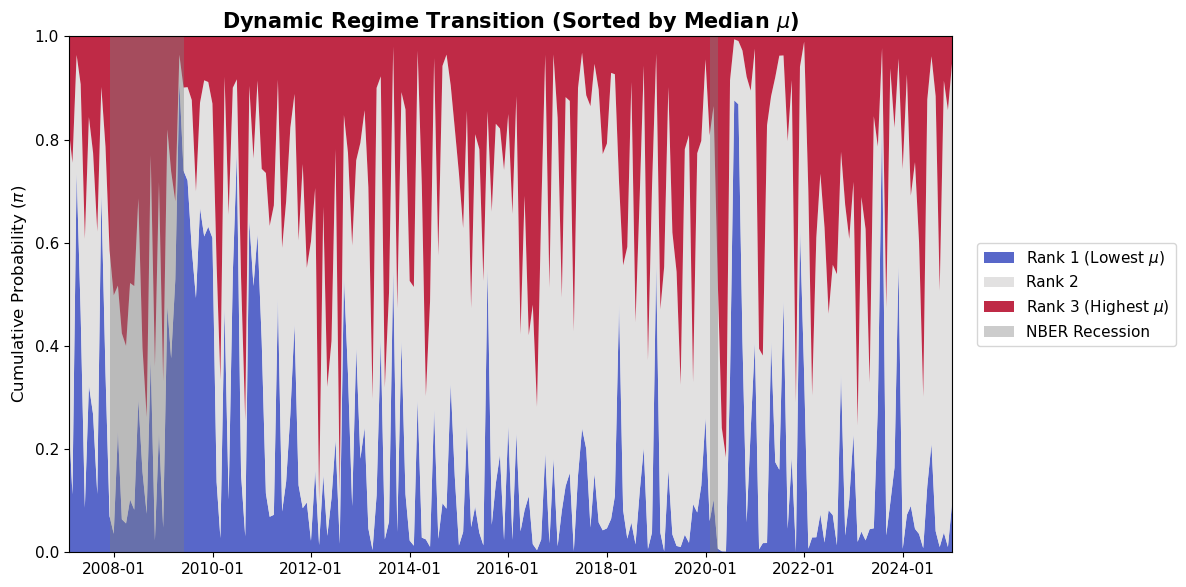

🔧 检测到模型通道数 K = 3
📊 正在按照 MEAN of SIGMA 进行横截面动态重排序...
✅ 图表已保存至 ../paper/fig/macro_regime_nber_sigma.pdf


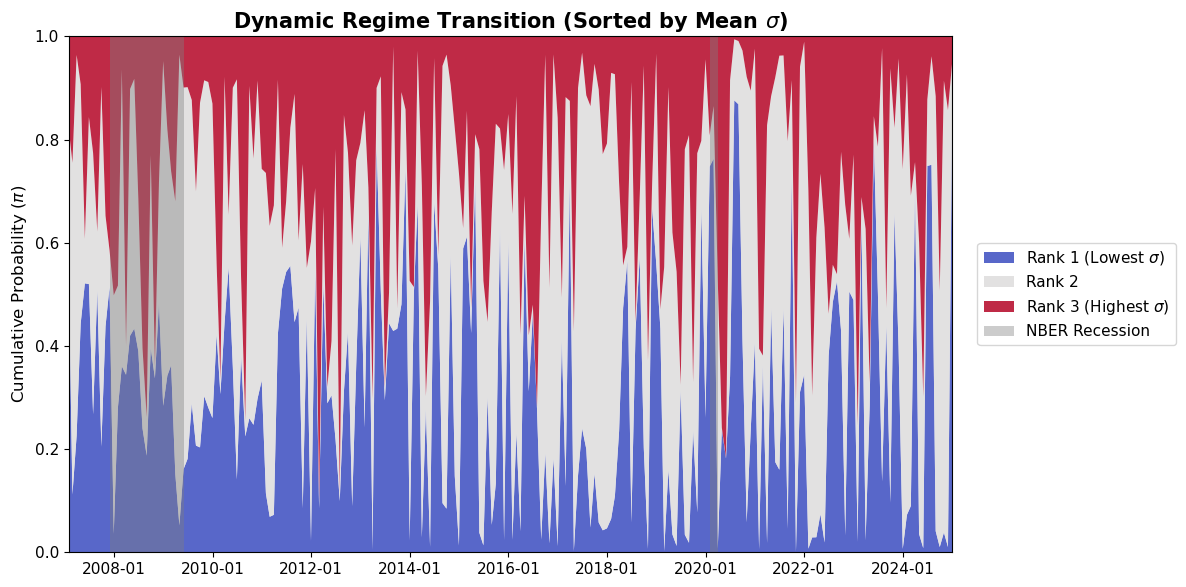

In [12]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_dynamic_sorted_pi(df_preds, time_col='mthcaldt', sort_by='mu', agg_method='median', save_path=None):
    """
    终极动态排序版：自动适应任意 K 值，并支持按 mu/sigma 和 mean/median 进行状态重排序。
    
    参数:
    - sort_by: 'mu' 或 'sigma' (决定用哪个指标来重排通道，默认 'mu')
    - agg_method: 'median' 或 'mean' (决定横截面上如何汇总数据，默认 'median')
    """
    df = df_preds.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    
    # 1. 安全解析数据，并自动识别通道数 K
    for col in ['pi_vec', 'mu_vec', 'sigma_vec']:
        if isinstance(df[col].iloc[0], str):
            df[f'{col}_arr'] = df[col].apply(lambda x: np.array(json.loads(x)))
        else:
            df[f'{col}_arr'] = df[col].apply(np.array)
            
    # 动态获取 K 值
    num_components = len(df['pi_vec_arr'].iloc[0])
    print(f"🔧 检测到模型通道数 K = {num_components}")
    print(f"📊 正在按照 {agg_method.upper()} of {sort_by.upper()} 进行横截面动态重排序...")

    # 确定使用的聚合函数
    agg_func = np.median if agg_method == 'median' else np.mean

    # 2. 逐月处理：计算指标并动态排序
    def process_month(group):
        mu_mat = np.vstack(group['mu_vec_arr'].values)
        sigma_mat = np.vstack(group['sigma_vec_arr'].values)
        
        # 计算截面汇总值 (K,)
        agg_mu = agg_func(mu_mat, axis=0)
        agg_sigma = agg_func(sigma_mat, axis=0)
        
        # 决定排序的基准指标
        if sort_by == 'mu':
            sort_metric = agg_mu
        elif sort_by == 'sigma':
            sort_metric = agg_sigma
        else:
            raise ValueError("sort_by 只能是 'mu' 或 'sigma'")
            
        pi_vec = group['pi_vec_arr'].iloc[0]
        
        # 核心：从小到大排序获取索引
        sort_idx = np.argsort(sort_metric)
        
        # 根据经济学顺序，重新排列 pi 和特征
        sorted_pi = pi_vec[sort_idx]
        sorted_metric = sort_metric[sort_idx]
        
        res = {}
        for i in range(num_components):
            res[f'pi_rank_{i}'] = sorted_pi[i]
            res[f'metric_rank_{i}'] = sorted_metric[i]
        return pd.Series(res)

    # 得到按月排序后的结果
    monthly_sorted = df.groupby(time_col).apply(process_month).reset_index()
    dates = monthly_sorted[time_col].values
    pi_matrix_sorted = monthly_sorted[[f'pi_rank_{i}' for i in range(num_components)]].values

    # 3. 动态生成图例标签 (自适应任意 K)
    metric_symbol = '$\mu$' if sort_by == 'mu' else '$\sigma$'
    regime_labels = []
    for i in range(num_components):
        if i == 0:
            desc = f"Rank 1 (Lowest {metric_symbol})"
        elif i == num_components - 1:
            desc = f"Rank {i+1} (Highest {metric_symbol})"
        else:
            desc = f"Rank {i+1}"
        regime_labels.append(desc)

    # 4. 定义美国 NBER 经济衰退期
    nber_recessions = [
        ('2001-03-01', '2001-11-01'), 
        ('2007-12-01', '2009-06-01'), 
        ('2020-02-01', '2020-04-01')  
    ]
    
    # 5. 开始绘图
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 动态渐变色：从蓝(Rank 1) 到 红(Rank K)
    colors = plt.cm.coolwarm(np.linspace(0, 1, num_components))
    
    ax.stackplot(dates, pi_matrix_sorted.T, labels=regime_labels, colors=colors, alpha=0.85)
    
    # 画 NBER 阴影
    for start, end in nber_recessions:
        start_date, end_date = pd.to_datetime(start), pd.to_datetime(end)
        if start_date <= dates[-1] and end_date >= dates[0]:
            ax.axvspan(start_date, end_date, color='grey', alpha=0.4, lw=0, 
                       label='NBER Recession' if start == '2007-12-01' else "")
            
    ax.set_title(f"Dynamic Regime Transition (Sorted by {agg_method.capitalize()} {metric_symbol})", fontsize=15, fontweight='bold')
    ax.set_ylabel("Cumulative Probability ($\pi$)", fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.margins(x=0) 
    
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=0)
    
    # 调整图例
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
        print(f"✅ 图表已保存至 {save_path}")
        
    plt.show()

plot_dynamic_sorted_pi(final_oos_df, sort_by='mu', agg_method='median',  save_path='../paper/fig/macro_regime_nber_mu.pdf')
plot_dynamic_sorted_pi(final_oos_df, sort_by='sigma', agg_method='mean', save_path='../paper/fig/macro_regime_nber_sigma.pdf')

### ES 5%

In [13]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

signal = "es_5"

# ES_df: permno, mthcaldt, es_5, realized_ret, vol_pred, mean_pred
# micro_df: permno, mthcaldt, mthcap, bm, MOM12m, ffi49, target_ret_final
cols = [
    "permno", "mthcaldt", "mthcap", "bm",
    "MOM12m", "ffi49", "target_ret_final"
]

df = ES_df.merge(
    micro_df[cols],
    on=["permno", "mthcaldt"],
    how="inner",
    validate="one_to_one"
)

df["mthcaldt"] = pd.to_datetime(df["mthcaldt"]) + pd.offsets.MonthEnd(0)
df["ret_date"] = df["mthcaldt"] + pd.offsets.MonthEnd(1)
df["mthcap_log"] = np.log(df["mthcap"])

# 确认 ES_df 与原始数据中的下一月收益完全一致
assert np.allclose(
    df["realized_ret"],
    df["target_ret_final"],
    equal_nan=True
)



In [14]:
def quantile_group(series, groups=10):
    """使用月内排名分组，避免 qcut 因重复值报错。"""
    rank = series.rank(method="first", pct=True)
    return np.ceil(rank * groups).clip(1, groups).astype("Int64")


df["es_decile"] = (
    df.groupby("mthcaldt")[signal]
      .transform(lambda x: quantile_group(x, 10))
)

group_keys = ["mthcaldt", "es_decile"]

# Equal-weighted returns
ew_ret = (
    df.groupby(group_keys)["realized_ret"]
      .mean()
      .unstack("es_decile")
)

# Value-weighted returns，使用形成月 t 的市值
vw_numerator = (
    df.assign(weighted_ret=df["mthcap"] * df["realized_ret"])
      .groupby(group_keys)["weighted_ret"]
      .sum()
)

vw_denominator = df.groupby(group_keys)["mthcap"].sum()

vw_ret = (
    (vw_numerator / vw_denominator)
    .unstack("es_decile")
)

# 高 ES 减低 ES
ew_ret["H-L"] = ew_ret[10] - ew_ret[1]
vw_ret["H-L"] = vw_ret[10] - vw_ret[1]

In [15]:
def nw_mean_stats(series, lags=6):
    x = series.dropna().astype(float)

    result = sm.OLS(
        x.to_numpy(),
        np.ones((len(x), 1))
    ).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": lags}
    )

    return pd.Series({
        "Monthly Mean (%)": x.mean() * 100,
        "Annualized Mean (%)": x.mean() * 12 * 100,
        "NW t-stat": result.tvalues[0]
    })


ew_summary = ew_ret.apply(nw_mean_stats).T
vw_summary = vw_ret.apply(nw_mean_stats).T

display(ew_summary)
display(vw_summary)

# 主结果看：
# Decile 1到10是否大致单调；
# VW H–L 是否为正；
# EW H–L 是否为正；
# H–L 的 Newey–West t-stat。

,Monthly Mean (%),Annualized Mean (%),NW t-stat
es_decile,,,
1,0.690650,8.287800,2.585799
2,0.802582,9.630988,2.674894
3,0.891922,10.703066,2.715531
4,0.865863,10.390357,2.516846
5,0.909339,10.912068,2.370837
6,0.949691,11.396292,2.387657
7,0.849437,10.193242,1.933531
8,0.755026,9.060313,1.530254
9,0.651753,7.821034,1.165247


,Monthly Mean (%),Annualized Mean (%),NW t-stat
es_decile,,,
1,0.784078,9.408937,3.139548
2,0.965600,11.587195,3.266395
3,0.897227,10.766727,2.581241
4,1.024318,12.291820,2.702389
5,0.906065,10.872783,2.189315
6,0.972692,11.672303,2.144374
7,1.107629,13.291554,1.985696
8,1.286886,15.442631,1.939504
9,0.722120,8.665443,1.084650


In [16]:
print("=== Starting Phase 4: Institutional Asset Pricing Tests ===")
WRDS_db_path = '/Users/jianbinchen/NonSync/GitHub/Research/DataSet/WRDS.sqlite'

# =================================================================
# 第一步：数据对齐与严格清洗 (Data Merging & Cleaning)
# =================================================================
print("\n>>> 1. Merging Data and Applying Universe Filters...")

with sqlite3.connect(WRDS_db_path) as conn:
    ff_factors_monthly = pd.read_sql_query("SELECT * FROM ff_factors_monthly", conn)
    ff_fivefactors_monthly = pd.read_sql_query("SELECT * FROM ff_fivefactors_monthly", conn)

ff_fivefactors_monthly.head(5)

=== Starting Phase 4: Institutional Asset Pricing Tests ===

>>> 1. Merging Data and Applying Universe Filters...


,date,mktrf,smb,hml,rmw,cma,rf,year,month,umd,dateff
0,1963-07-01 00:00:00,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027,1963.0,7.0,0.0101,1963-07-31 00:00:00
1,1963-08-01 00:00:00,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025,1963.0,8.0,0.0100,1963-08-30 00:00:00
2,1963-09-01 00:00:00,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027,1963.0,9.0,0.0012,1963-09-30 00:00:00
3,1963-10-01 00:00:00,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029,1963.0,10.0,0.0313,1963-10-31 00:00:00
4,1963-11-01 00:00:00,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027,1963.0,11.0,-0.0078,1963-11-29 00:00:00


In [17]:
def factor_alpha(long_short, factor_df, factor_cols, lags=6):
    portfolio = long_short.rename("ES_HL").dropna().reset_index()
    portfolio["ret_date"] = (
        pd.to_datetime(portfolio["mthcaldt"])
        + pd.offsets.MonthEnd(1)
    )

    factors = factor_df.copy()
    factors["ret_date"] = (
        pd.to_datetime(factors["date"])
        + pd.offsets.MonthEnd(0)
    )

    regression_df = portfolio.merge(
        factors[["ret_date"] + factor_cols],
        on="ret_date",
        how="inner",
        validate="one_to_one"
    ).dropna()

    # H-L 是零成本组合，不需要减 RF
    y = regression_df["ES_HL"]
    X = sm.add_constant(regression_df[factor_cols])

    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": lags}
    )

    return pd.DataFrame({
        "Coefficient": model.params,
        "t-stat": model.tvalues
    })


alpha_capm = factor_alpha(
    vw_ret["H-L"], ff_fivefactors_monthly, ["mktrf"]
)

alpha_ff3 = factor_alpha(
    vw_ret["H-L"], ff_fivefactors_monthly, ["mktrf", "smb", "hml"]
)

alpha_carhart = factor_alpha(
    vw_ret["H-L"], ff_fivefactors_monthly, ["mktrf", "smb", "hml", "umd"]
)

alpha_ff5_mom = factor_alpha(
    vw_ret["H-L"], ff_fivefactors_monthly,
    ["mktrf", "smb", "hml", "rmw", "cma", "umd"]
)

display(alpha_capm)
display(alpha_ff3)
display(alpha_carhart)
display(alpha_ff5_mom)

,Coefficient,t-stat
const,-0.011053,-2.568881
mktrf,0.897038,8.723866


,Coefficient,t-stat
const,-0.009243,-3.105916
mktrf,0.601815,6.103593
smb,1.843241,11.053876
hml,-0.754002,-5.985410


,Coefficient,t-stat
const,-0.008777,-2.935210
mktrf,0.552252,6.029582
smb,1.802401,10.641065
hml,-0.812285,-7.747301
umd,-0.170525,-1.450175


,Coefficient,t-stat
const,-0.003063,-1.209618
mktrf,0.494727,6.969646
smb,1.390548,10.084818
hml,-0.632612,-6.045249
rmw,-1.431254,-7.087629
cma,-0.172129,-0.898089
umd,-0.176766,-1.366549


Fama–MacBeth 回归

推荐依次估计：

$$
r_{i,t+1}=a_t+b_t ES_{i,t}+\varepsilon_{i,t+1}
$$

然后增加：

log size；

BM；

momentum；

predicted volatility。

月内使用 percentile rank，避免 ES 和公司特征的极端值主导回归。

In [18]:
def fama_macbeth(data, x_vars, lags=6):
    coefficient_rows = []

    for date, month_df in data.groupby("mthcaldt"):
        month_df = month_df.dropna(
            subset=["realized_ret"] + x_vars
        ).copy()

        if len(month_df) < 100:
            continue

        ranked_vars = []
        for col in x_vars:
            ranked_col = f"{col}_rank"
            month_df[ranked_col] = (
                month_df[col].rank(pct=True) - 0.5
            )
            ranked_vars.append(ranked_col)

        y = month_df["realized_ret"]
        X = sm.add_constant(month_df[ranked_vars])

        params = sm.OLS(y, X).fit().params
        params.name = date
        coefficient_rows.append(params)

    monthly_coefs = pd.DataFrame(coefficient_rows)

    summary_rows = []
    for col in monthly_coefs.columns:
        values = monthly_coefs[col].dropna()

        result = sm.OLS(
            values.to_numpy(),
            np.ones((len(values), 1))
        ).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": lags}
        )

        summary_rows.append({
            "Variable": col,
            "Monthly Coefficient (%)": result.params[0] * 100,
            "NW t-stat": result.tvalues[0]
        })

    return monthly_coefs, pd.DataFrame(summary_rows).set_index("Variable")

 # ES 单变量
fm_1, fm_summary_1 = fama_macbeth(
    df, [signal]
)

# 加入常见公司特征
fm_2, fm_summary_2 = fama_macbeth(
    df, [signal, "mthcap_log", "bm", "MOM12m"]
)

# 检验 ES 是否包含超过整体波动率的信息
fm_3, fm_summary_3 = fama_macbeth(
    df, [signal, "mthcap_log", "bm", "MOM12m", "vol_pred"]
)

display(fm_summary_1)
display(fm_summary_2)
display(fm_summary_3)

,Monthly Coefficient (%),NW t-stat
Variable,,
const,0.748713,1.917059
es_5_rank,-0.435995,-0.845426


,Monthly Coefficient (%),NW t-stat
Variable,,
const,0.748644,1.917051
es_5_rank,-0.471824,-0.867014
mthcap_log_rank,0.129381,0.486475
bm_rank,-0.050862,-0.153831
MOM12m_rank,0.476008,1.465541


,Monthly Coefficient (%),NW t-stat
Variable,,
const,0.748665,1.917057
es_5_rank,-6.282322,-4.236622
mthcap_log_rank,0.170090,0.609147
bm_rank,-0.069775,-0.209883
MOM12m_rank,0.342212,0.967980
vol_pred_rank,5.816174,3.558175


5. 控制波动率后的 Double Sort
先按照波动率分5组，再在每个波动率组内按照 ES 分5组。

In [19]:
def sequential_double_sort(
    data,
    control,
    signal="es_5",
    groups=5
):
    temp = data.dropna(
        subset=[control, signal, "realized_ret", "mthcap"]
    ).copy()

    # 第一层：控制变量分组
    temp["control_group"] = (
        temp.groupby("mthcaldt")[control]
            .transform(lambda x: quantile_group(x, groups))
    )

    # 第二层：在每个控制组内按照 ES 分组
    temp["es_group"] = (
        temp.groupby(["mthcaldt", "control_group"])[signal]
            .transform(lambda x: quantile_group(x, groups))
    )

    keys = ["mthcaldt", "control_group", "es_group"]

    numerator = (
        temp.assign(weighted_ret=temp["mthcap"] * temp["realized_ret"])
            .groupby(keys)["weighted_ret"]
            .sum()
    )
    denominator = temp.groupby(keys)["mthcap"].sum()

    cell_returns = numerator / denominator

    # 在各控制组之间等权平均
    portfolios = (
        cell_returns
        .groupby(level=["mthcaldt", "es_group"])
        .mean()
        .unstack("es_group")
    )

    portfolios["H-L"] = portfolios[groups] - portfolios[1]
    return portfolios

# 控制总体预测波动率
vol_controlled = sequential_double_sort(
    df, control="vol_pred", signal=signal
)

# 控制公司规模
size_controlled = sequential_double_sort(
    df, control="mthcap_log", signal=signal
)

display(vol_controlled.apply(nw_mean_stats).T)
display(size_controlled.apply(nw_mean_stats).T)

,Monthly Mean (%),Annualized Mean (%),NW t-stat
es_group,,,
1,0.858358,10.300298,2.054167
2,0.793738,9.524851,1.891429
3,0.900444,10.805329,2.077031
4,1.003444,12.041332,2.184632
5,0.823720,9.884642,1.794823
H-L,-0.034638,-0.415656,-0.186084


,Monthly Mean (%),Annualized Mean (%),NW t-stat
es_group,,,
1,0.783728,9.404731,2.745368
2,0.877038,10.524457,2.627181
3,0.902614,10.831369,2.323721
4,0.814301,9.771608,1.730378
5,0.537994,6.455933,0.932200
H-L,-0.245733,-2.948798,-0.542235


论文主表建议
主结果至少包括：
Table 1：ES decile EW/VW returns 与 H–L；
Table 2：H–L 的 CAPM、FF3、Carhart、FF5+Mom alpha；
Table 3：Fama–MacBeth 三组 specification；
Table 4：控制 size、volatility 后的 double sorts。
稳健性部分再加入：
es_1、es_10；
K1 Normal、K1 Student-t、quantile benchmark 的 ES；
排除 microcaps；
EW与VW；
2007–2015、2016–2024子样本；
turnover和交易成本。
核心判断不是只有 H–L 显著，而是：收益是否随 ES 单调变化、风险调整 alpha 是否存在、Fama–MacBeth 系数是否稳定，以及控制 vol_pred 后结果是否仍然存在。

### ---------------------------------------------------
### 下面是旧的, 先不要了
### ---------------------------------------------------

In [ ]:
print("=== Starting Phase 4: Institutional Asset Pricing Tests ===")
WRDS_db_path = '/Users/jianbinchen/NonSync/GitHub/Research/DataSet/WRDS.sqlite'

# =================================================================
# 第一步：数据对齐与严格清洗 (Data Merging & Cleaning)
# =================================================================
print("\n>>> 1. Merging Data and Applying Universe Filters...")

with sqlite3.connect(WRDS_db_path) as conn:
    ff_factors_monthly = pd.read_sql_query("SELECT * FROM ff_factors_monthly", conn)
    ff_fivefactors_monthly = pd.read_sql_query("SELECT * FROM ff_fivefactors_monthly", conn)

def run_institutional_asset_pricing_tests(ff_df,ff_factors):
    ff_df['date'] = pd.to_datetime(ff_df['date'])+pd.offsets.MonthEnd(0)

    # =================================================================
    # 第四步：投资组合 Alpha 测试 (Time-Series Factor Spanning Test)
    # =================================================================
    print("\n>>> 4. Running Portfolio Alpha Test (Fama-French 5-Factor)...")

    # 提取我们的 High-Low 零成本多空投资组合的时间序列收益率
    port_ret = vw_ret[['High-Low']].dropna().reset_index()
    port_ret.columns = ['date', 'High_Low_Ret']

    # 对齐日期并合并 (必须使用 inner join 确保时间严丝合缝)
    alpha_df = pd.merge(port_ret, ff_df, on='date', how='inner')

    # 构造回归模型：
    # 因为 High-Low 是做多做空的“零投资组合”，所以左侧因变量不需要再减去无风险利率 (RF)
    # y = High_Low_Ret
    # X = 'mktrf','smb','hml','umd', 'rmw','cma'

    y_alpha = alpha_df['High_Low_Ret']

    X_alpha = alpha_df[ff_factors]
    X_alpha = sm.add_constant(X_alpha) # 截距项就是我们要找的 Alpha！

    # 进行时序回归 (同样使用 Newey-West HAC 调整)
    alpha_model = sm.OLS(y_alpha, X_alpha).fit(cov_type='HAC', cov_kwds={'maxlags': 6})

    print("\n--- Fama-French 5-Factor Time-Series Regression ---")
    print(alpha_model.summary().tables[1]) # 只打印核心的系数表

    alpha_val = alpha_model.params['const']
    alpha_t = alpha_model.tvalues['const']
    print(f"\n🌟 Monthly FF5 Alpha: {alpha_val:.3f}% (t-stat: {alpha_t:.2f})")
    print(f"🌟 Annualized Alpha : {alpha_val * 12:.2f}%")


    print("\n=== Phase 4 Complete! ===")

# Fama-French 3-Factor + Momentum
run_institutional_asset_pricing_tests(ff_factors_monthly, ['mktrf','smb','hml','umd'])
# Fama-French 5-Factor + Momentum
run_institutional_asset_pricing_tests(ff_fivefactors_monthly, ['mktrf','smb','hml','umd','rmw','cma'])

In [19]:
micro_df.head(5)

,permno,mthcaldt,mthret,mthprc,mthcap,siccd,gvkey,bm,evm,pe_exi,ps,pcf,pfcf,npm,opmad,gpm,cfm,roe,aftret_invcapx,gprof,debt_at,debt_ebitda,short_debt,ocf_lct,de_ratio,cash_ratio,curr_ratio,at_turn,rect_turn,pay_turn,sale_equity,rd_sale,adv_sale,staff_sale,accrual,ffi49,target_ret_final,MOM12m,mu_bench,sigma_bench,mthcap_log
0,10001,1991-01-31,0.013158,9.625,10144.75,4920.0,012994,0.896385,5.690808,3.307560,0.445982,4.872598,14.070388,0.044401,0.099749,0.138304,0.082956,0.112235,0.112708,0.161306,0.392076,2.430626,0.061202,0.672101,1.796365,0.316439,1.340247,1.166318,8.789413,10.931698,3.261452,0.0,0.0,0.0,-0.055775,31,0.012987,0.009425,0.002110,0.022682,9.224712
1,10001,1991-02-28,0.012987,9.750,10276.50,4920.0,012994,0.975332,5.299653,3.037383,0.434947,5.205927,14.253121,0.047361,0.103356,0.141152,0.085157,0.121406,0.116860,0.168351,0.378677,2.249325,0.050190,0.614188,1.755852,0.289359,1.348320,1.192696,8.491285,10.618904,3.286892,0.0,0.0,0.0,-0.042869,31,-0.012244,0.029179,0.003717,0.022716,9.237615
2,10001,1991-03-31,-0.012244,9.500,10013.00,4920.0,012994,0.975332,5.299653,2.959502,0.423795,5.072442,13.887656,0.047361,0.103356,0.141152,0.085157,0.121406,0.116860,0.168351,0.378677,2.249325,0.050190,0.614188,1.755852,0.289359,1.348320,1.192696,8.491285,10.618904,3.286892,0.0,0.0,0.0,-0.042869,31,0.039474,0.029348,0.001628,0.022954,9.211640
3,10001,1991-04-30,0.039474,9.875,10408.25,4920.0,012994,0.975332,5.299653,3.115265,0.446100,5.339412,14.618585,0.047361,0.103356,0.141152,0.085157,0.121406,0.116860,0.168351,0.378677,2.249325,0.050190,0.614188,1.755852,0.289359,1.348320,1.192696,8.491285,10.618904,3.286892,0.0,0.0,0.0,-0.042869,31,0.000000,0.016744,0.004917,0.025398,9.250354
4,10001,1991-05-31,0.000000,9.875,10408.25,4920.0,012994,1.040348,5.316239,3.086420,0.444182,6.893394,14.618585,0.047832,0.103923,0.139492,0.083400,0.119963,0.115336,0.165372,0.375721,2.271979,0.059539,0.472059,1.708091,0.318617,1.389858,1.185531,8.331080,10.836074,3.210526,0.0,0.0,0.0,-0.019640,31,0.079241,0.070429,0.005972,0.024859,9.250354


In [20]:
test_df = pd.merge(processed_df[['permno', 'mthcaldt', 'mthcap_log', 'target_ret_final', 'MOM12m']], micro_df[['permno', 'mthcaldt', 'mthcap', 'bm']],on=['permno', 'mthcaldt'], how='left')
display(pd.concat([test_df.head(5), test_df.tail(5)]))

,permno,mthcaldt,mthcap_log,target_ret_final,MOM12m,mthcap,bm
0,10001,1990-01-31,9.225833,-0.006289,0.000000,NaN,NaN
1,10002,1990-01-31,8.901605,0.020000,0.000000,NaN,NaN
2,10003,1990-01-31,9.741174,0.258065,0.000000,NaN,NaN
3,10009,1990-01-31,8.718745,0.173077,0.000000,NaN,NaN
4,10016,1990-01-31,12.653025,0.049029,0.000000,NaN,NaN
1601163,93374,2024-12-31,15.676729,0.012492,0.119151,6.431570e+06,0.758314
1601164,93397,2024-12-31,12.999767,-0.057236,0.361712,4.423102e+05,0.435276
1601165,93426,2024-12-31,12.566225,-0.007243,-0.325799,2.867095e+05,0.974849
1601166,93434,2024-12-31,9.746284,0.147685,-0.469924,1.709061e+04,3.796202
1601167,93436,2024-12-31,20.984828,0.001882,0.389088,1.298958e+09,0.083346


In [21]:
test_df.isna().sum()

permno                  0
mthcaldt                0
mthcap_log              0
target_ret_final        0
MOM12m                  0
mthcap              40808
bm                  40808
dtype: int64

In [14]:
ES_df.head(5)

,permno,mthcaldt,es_1,var_1,es_5,var_5,pit,crps,mean_pred,vol_pred,realized_ret
0,10001,2007-01-31,0.337987,-0.233005,0.197922,-0.125793,0.982970,0.208488,0.005945,0.102231,0.264774
1,10002,2007-01-31,0.195992,-0.134957,0.124361,-0.089782,0.652959,0.021521,0.014109,0.076592,0.033054
2,10025,2007-01-31,0.343822,-0.252985,0.232311,-0.175530,0.413901,0.027762,0.007513,0.131664,-0.028094
3,10026,2007-01-31,0.221054,-0.165309,0.150750,-0.113887,0.291119,0.026726,0.007411,0.084664,-0.038517
4,10032,2007-01-31,0.394016,-0.315035,0.288202,-0.228843,0.495257,0.032614,-0.010393,0.152493,-0.023810


In [15]:
micro_df.head(5)

,permno,mthcaldt,mthret,mthprc,mthcap,siccd,gvkey,bm,evm,pe_exi,ps,pcf,pfcf,npm,opmad,gpm,cfm,roe,aftret_invcapx,gprof,debt_at,debt_ebitda,short_debt,ocf_lct,de_ratio,cash_ratio,curr_ratio,at_turn,rect_turn,pay_turn,sale_equity,rd_sale,adv_sale,staff_sale,accrual,ffi49,target_ret_final,MOM12m,mu_bench,sigma_bench,mthcap_log
0,10001,1991-01-31,0.013158,9.625,10144.75,4920.0,012994,0.896385,5.690808,3.307560,0.445982,4.872598,14.070388,0.044401,0.099749,0.138304,0.082956,0.112235,0.112708,0.161306,0.392076,2.430626,0.061202,0.672101,1.796365,0.316439,1.340247,1.166318,8.789413,10.931698,3.261452,0.0,0.0,0.0,-0.055775,31,0.012987,0.009425,0.002110,0.022682,9.224712
1,10001,1991-02-28,0.012987,9.750,10276.50,4920.0,012994,0.975332,5.299653,3.037383,0.434947,5.205927,14.253121,0.047361,0.103356,0.141152,0.085157,0.121406,0.116860,0.168351,0.378677,2.249325,0.050190,0.614188,1.755852,0.289359,1.348320,1.192696,8.491285,10.618904,3.286892,0.0,0.0,0.0,-0.042869,31,-0.012244,0.029179,0.003717,0.022716,9.237615
2,10001,1991-03-31,-0.012244,9.500,10013.00,4920.0,012994,0.975332,5.299653,2.959502,0.423795,5.072442,13.887656,0.047361,0.103356,0.141152,0.085157,0.121406,0.116860,0.168351,0.378677,2.249325,0.050190,0.614188,1.755852,0.289359,1.348320,1.192696,8.491285,10.618904,3.286892,0.0,0.0,0.0,-0.042869,31,0.039474,0.029348,0.001628,0.022954,9.211640
3,10001,1991-04-30,0.039474,9.875,10408.25,4920.0,012994,0.975332,5.299653,3.115265,0.446100,5.339412,14.618585,0.047361,0.103356,0.141152,0.085157,0.121406,0.116860,0.168351,0.378677,2.249325,0.050190,0.614188,1.755852,0.289359,1.348320,1.192696,8.491285,10.618904,3.286892,0.0,0.0,0.0,-0.042869,31,0.000000,0.016744,0.004917,0.025398,9.250354
4,10001,1991-05-31,0.000000,9.875,10408.25,4920.0,012994,1.040348,5.316239,3.086420,0.444182,6.893394,14.618585,0.047832,0.103923,0.139492,0.083400,0.119963,0.115336,0.165372,0.375721,2.271979,0.059539,0.472059,1.708091,0.318617,1.389858,1.185531,8.331080,10.836074,3.210526,0.0,0.0,0.0,-0.019640,31,0.079241,0.070429,0.005972,0.024859,9.250354


In [22]:
# =================================================================
# Phase 4: 资产定价终极测试 (Asset Pricing Tests)
# 1. 10分位组合排序 (Decile Sorts)
# 2. Fama-MacBeth 截面回归 (Cross-Sectional Regression)
# 3. 投资组合 Alpha 测试 (Time-Series Factor Spanning Test)
# =================================================================

# 1. 对齐日期列进行合并
# ES_df 的日期叫 'date', processed_df 的日期叫 'mthcaldt'
df_micro_subset = processed_df[['permno', 'mthcaldt', 'mthcap', 'bm', 'MOM12m', 'target_ret_final']]
df_micro_subset = test_df
# df_micro_subset['mthcap_log'] = np.log(df_micro_subset['mthcap'])
df = pd.merge(ES_df, df_micro_subset, 
              on=['permno', 'mthcaldt'], 
              how='inner')

# =================================================================
# 第二步：市值加权 10 分位测试 (Value-Weighted Decile Sorts)
# =================================================================
print("\n>>> 2. Running Value-Weighted Portfolio Sorts...")

# 1. 按月对预期尾部风险 (es_5) 进行 10 等分
def get_deciles(x):
    # return pd.qcut(x, 10, labels=False, duplicates='drop') + 1
    # 在 pd.qcut 的默认设置下，第 10 组的 es_5 最大，第 1 组的 es_5 最小。
    return pd.qcut(x, 10, labels=False) + 1

df['decile'] = df.groupby('mthcaldt')['es_5'].transform(get_deciles)

# 2. 计算市值加权收益率 (VW Returns)
def vw_return(group):
    if group['mthcap'].sum() == 0: 
        return np.nan
    # 使用 t 时刻的市值 (mthcap) 作为权重，加权 t+1 期的真实收益率 (target_ret_final)
    return np.average(group['target_ret_final'], weights=group['mthcap'])

# 计算各组每月的加权收益率
vw_ret = df.groupby(['mthcaldt', 'decile']).apply(vw_return).unstack()

# 构建多空组合 (Long-Short Portfolio)：做多风险最高组(10)，做空风险最低组(1)
# 这里 10 代表尾部风险最大
vw_ret['High-Low'] = vw_ret[10] - vw_ret[1]

# 3. 统计输出表
print("\n--- Value-Weighted Decile Portfolios (Monthly Returns %) ---")
summary_vw = pd.DataFrame(index=vw_ret.columns)
summary_vw['Mean (Ann. %)'] = vw_ret.mean() * 12 * 100
summary_vw['Vol (Ann. %)']  = vw_ret.std() * np.sqrt(12) * 100
summary_vw['Sharpe']        = summary_vw['Mean (Ann. %)'] / summary_vw['Vol (Ann. %)']
# 计算均值是否显著异于 0 的 t 统计量
def get_nw_tstat(x, lags=None):
    # 自动选择滞后阶数，常用的是 lags=int(4*(n/100)**(2/9))
    x = x.dropna()
    n = len(x)
    if lags is None: lags=int(4*(n/100)**(2/9))
    # if lags is None: lags = int(n**(1/4)) 
    
    # 对常数项回归，获取均值及其 Newey-West 标准误
    model = sm.OLS(x, np.ones(n)).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    return model.tvalues[0]

# 应用到你的数据上
summary_vw['t-stat'] = vw_ret.apply(get_nw_tstat)

print(summary_vw.round(2))


# =================================================================
# 第三步：Fama-MacBeth 截面回归 (Fama-MacBeth Regressions)
# =================================================================
print("\n>>> 3. Running Robust Fama-MacBeth Regressions...")

# Step 1: Cross-sectional regressions
def run_cs_reg(df_t):
    if len(df_t) < 50:
        return None
    
    df_t = df_t.copy()
    
    # winsorize (safer than scipy)
    lower = df_t['target_ret_final'].quantile(0.01)
    upper = df_t['target_ret_final'].quantile(0.99)
    y = df_t['target_ret_final'].clip(lower, upper) * 100
    
    # df_t['mthcap_log'] = np.log(df_t['mthcap'])
    X = df_t[['es_5', 'mthcap_log', 'MOM12m']]
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()
    return model.params

fm_coefs = df.groupby('mthcaldt').apply(run_cs_reg).dropna()

# Step 2: Newey-West adjusted inference
T = len(fm_coefs)
lag = int(4 * (T / 100) ** (2/9))   # 更规范的lag选择

results = []
for col in fm_coefs.columns:
    y = fm_coefs[col]
    
    res = sm.OLS(y, np.ones(len(y))).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': lag}
    )
    
    results.append({
        'Factor': col,
        'Coefficient': res.params[0],
        't-stat': res.tvalues[0],
        'p-value': res.pvalues[0]
    })

fm_summary = pd.DataFrame(results).set_index('Factor')


print("\n--- Fama-MacBeth Regression Results ---")
print("Dep. Variable: Next Month Return (%) [Winsorized]")
print("Newey-West HAC Adjusted t-statistics")
print("-" * 50)
print(fm_summary.round(3))
print("-" * 50)



>>> 2. Running Value-Weighted Portfolio Sorts...

--- Value-Weighted Decile Portfolios (Monthly Returns %) ---
          Mean (Ann. %)  Vol (Ann. %)  Sharpe  t-stat
decile                                               
1                 11.03         17.29    0.64    2.97
2                 10.61         14.35    0.74    3.41
3                 11.77         15.24    0.77    3.47
4                 12.18         15.85    0.77    3.29
5                 11.99         16.82    0.71    2.99
6                 11.82         20.51    0.58    2.43
7                 11.41         22.85    0.50    2.00
8                 12.46         25.18    0.49    2.00
9                  7.91         26.99    0.29    1.18
10                 6.58         33.19    0.20    0.84
High-Low          -4.45         26.72   -0.17   -0.74

>>> 3. Running Robust Fama-MacBeth Regressions...

--- Fama-MacBeth Regression Results ---
Dep. Variable: Next Month Return (%) [Winsorized]
Newey-West HAC Adjusted t-statistics
-------


>>> 4. Generating Publication-Quality Plots (Matplotlib Only)...


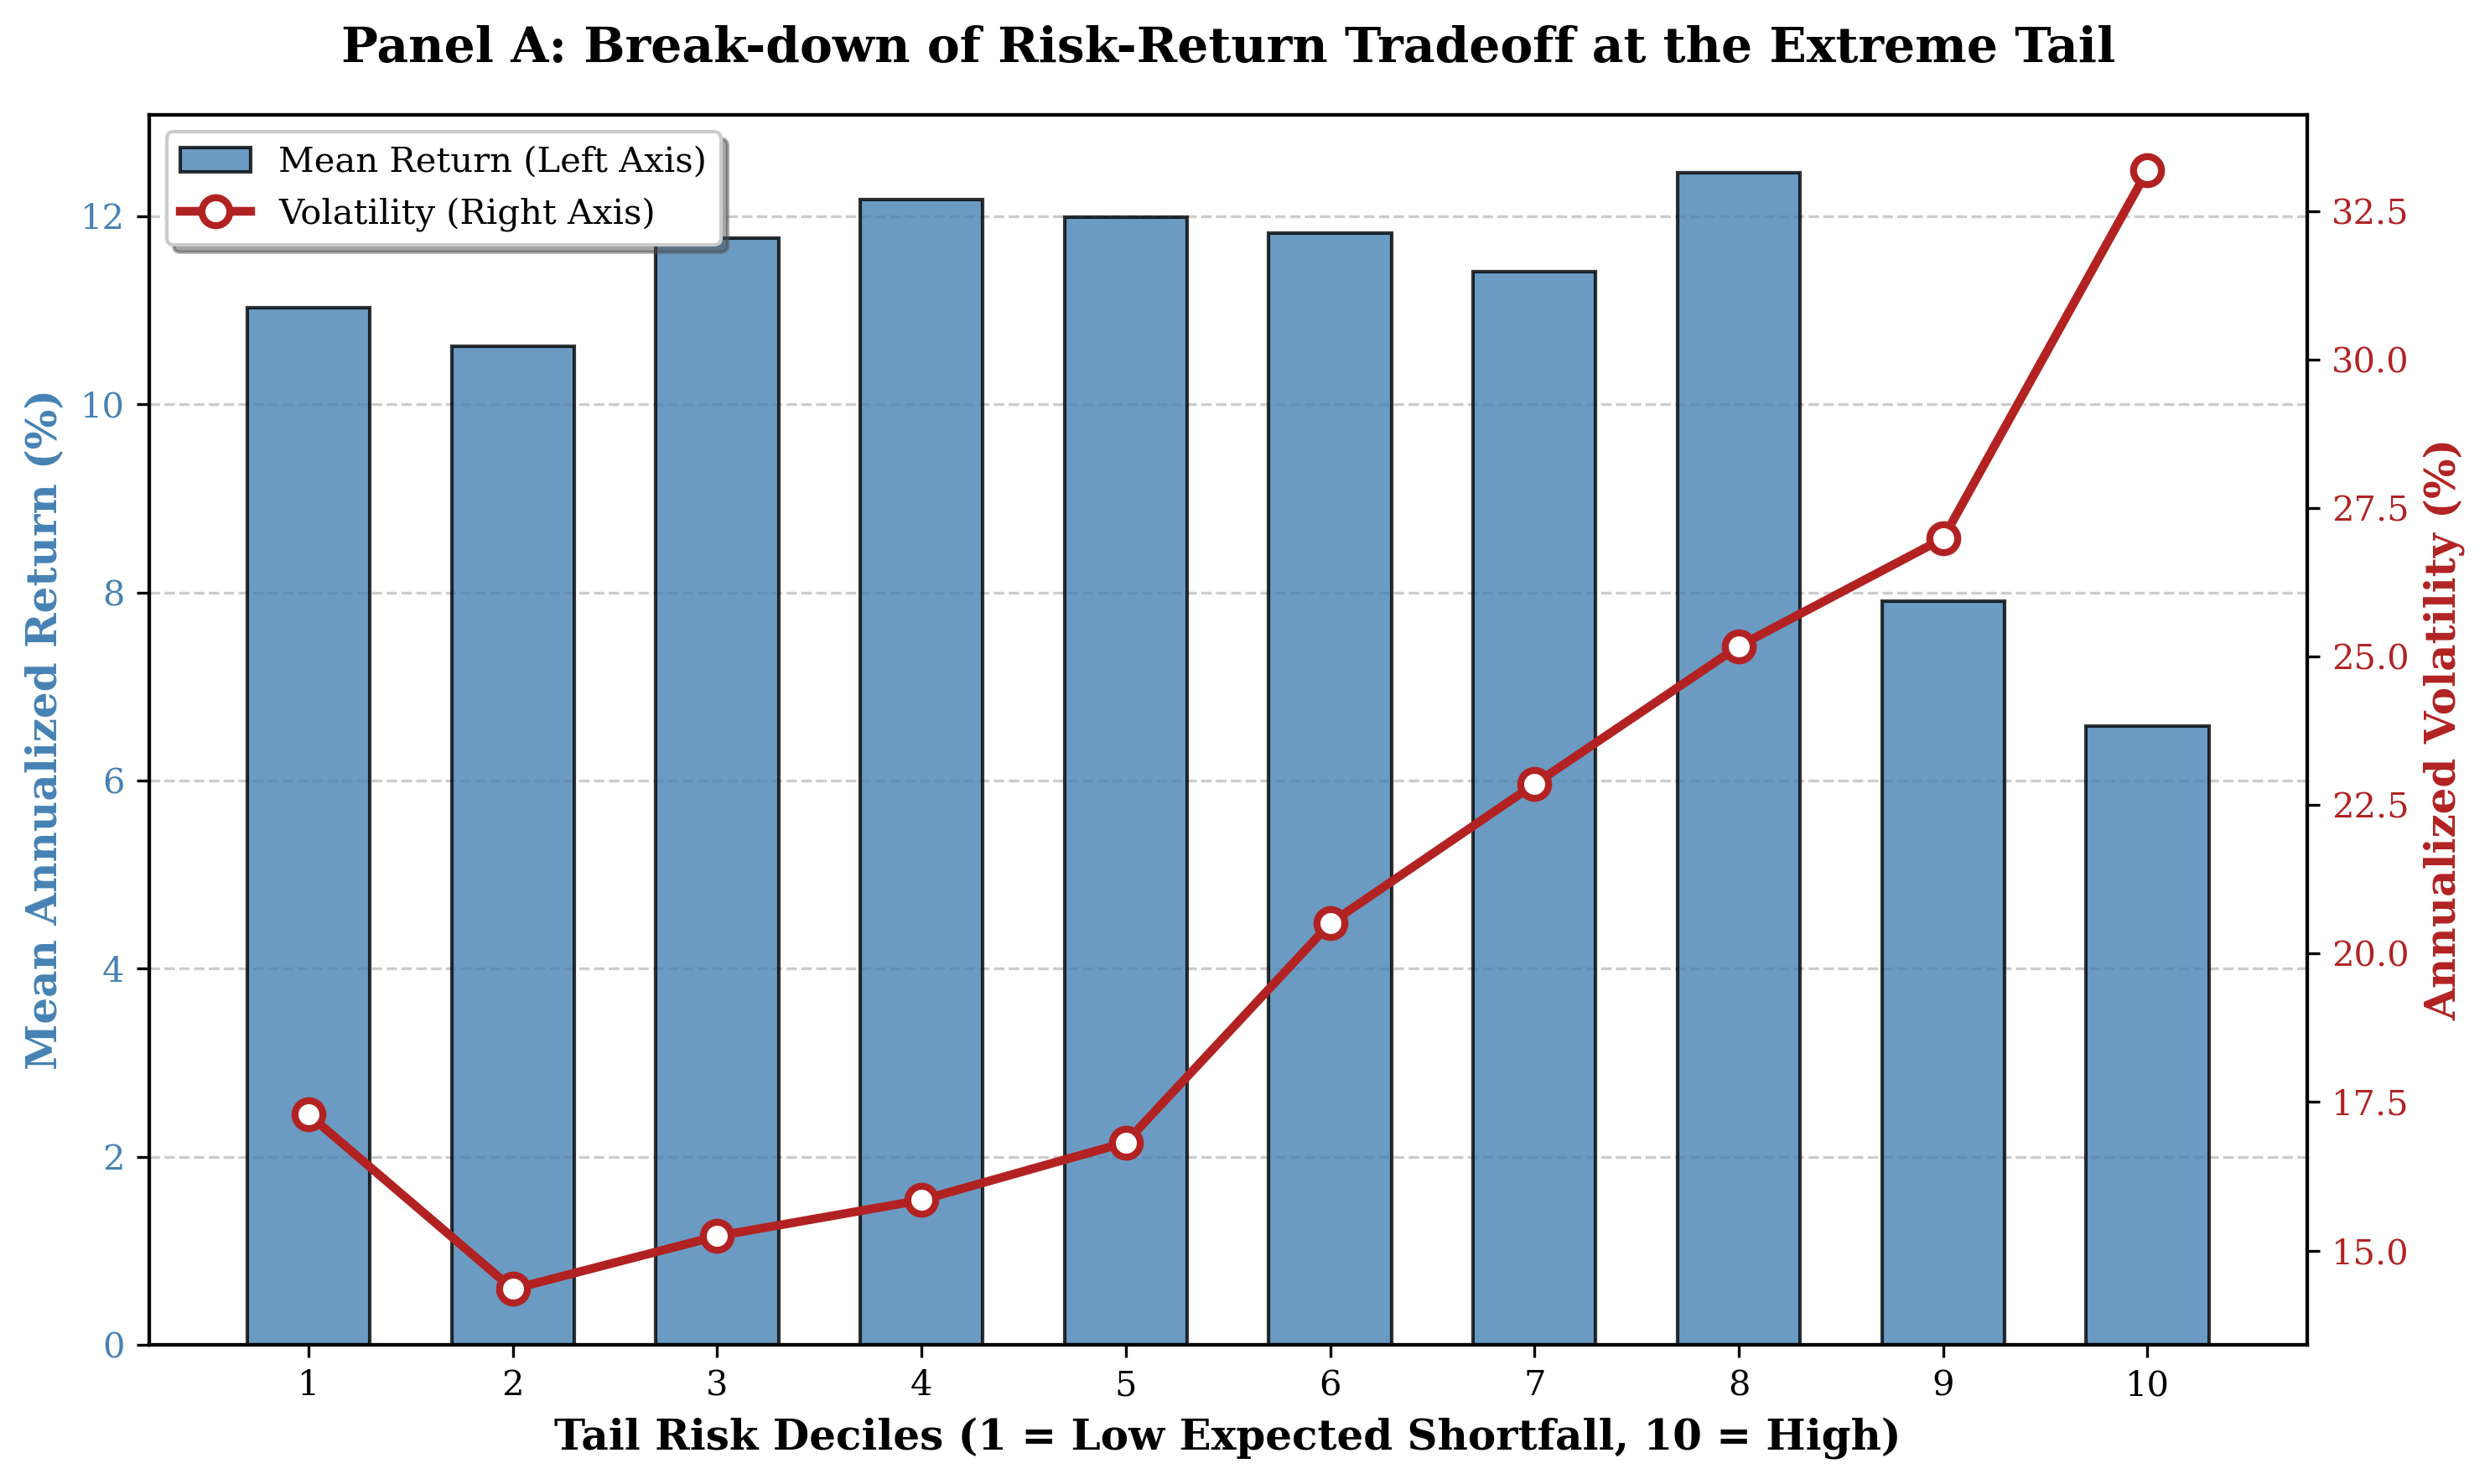

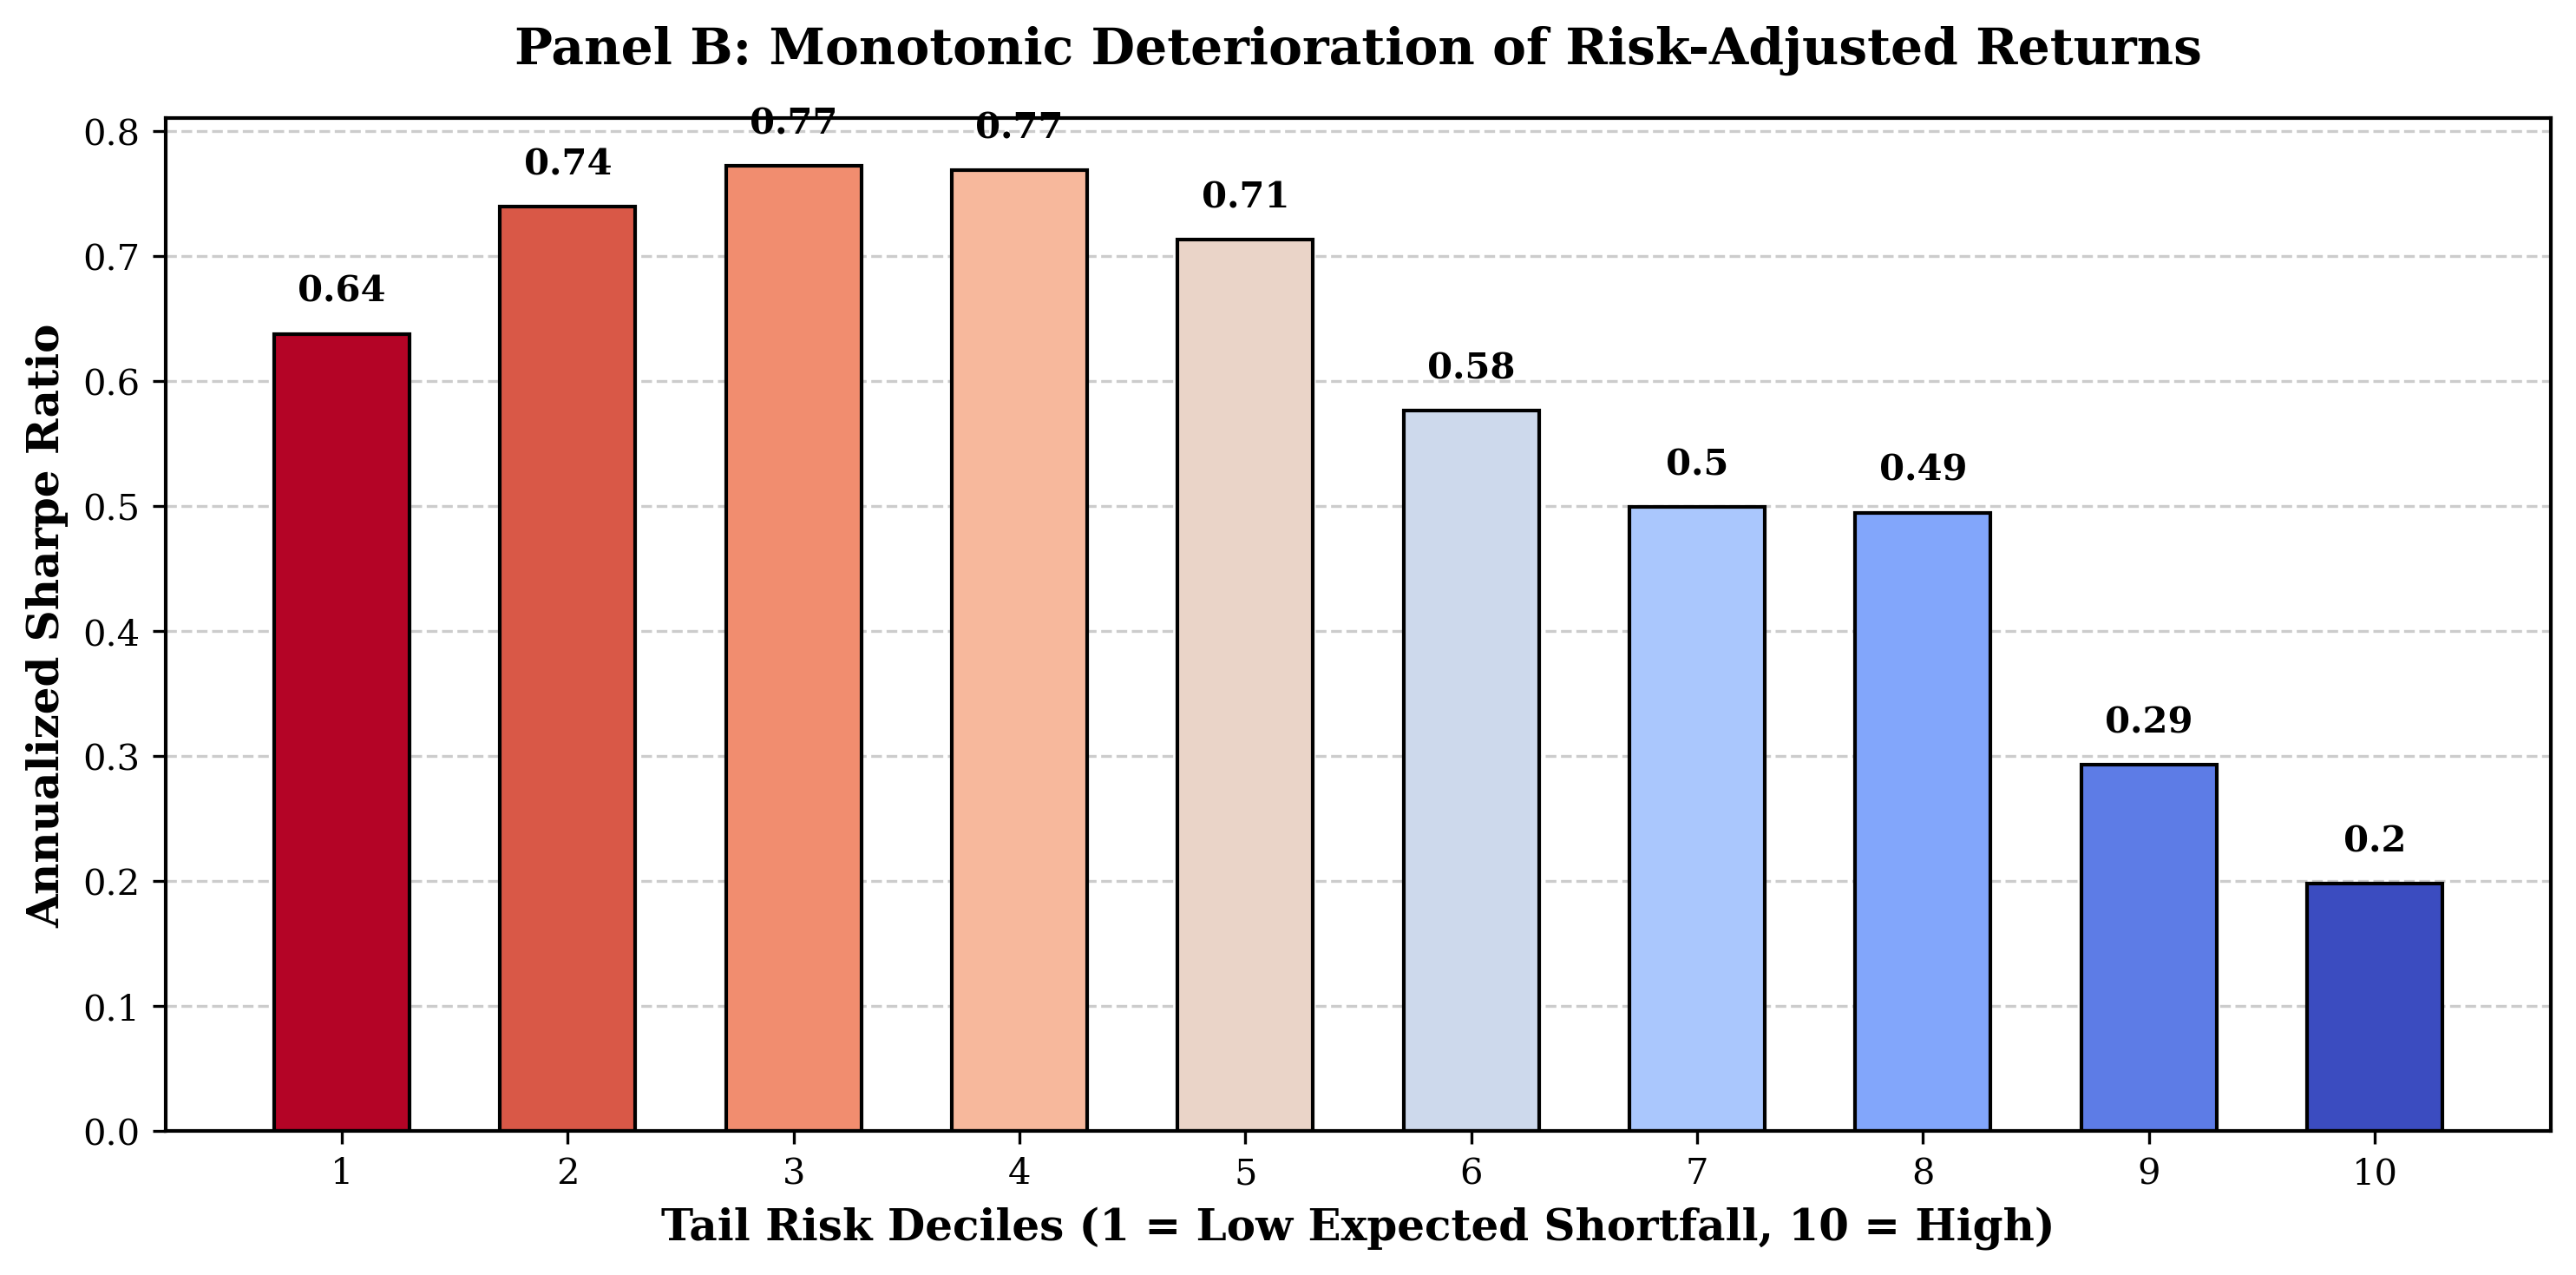

In [23]:
# =================================================================
# 第四步：学术级图表绘制 (Pure Matplotlib Version)
# =================================================================
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

print("\n>>> 4. Generating Publication-Quality Plots (Matplotlib Only)...")

# 设定学术图表风格 (纯 Matplotlib 原生设置)
plt.style.use('default')
plt.rcParams['font.family'] = 'serif'  # 使用衬线字体
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

# 准备绘图数据 (剔除多空组合 'High-Low' 行，只保留 1-10 组)
plot_df = summary_vw.drop('High-Low')
deciles = plot_df.index.astype(int)

# -----------------------------------------------------------------
# 图 A (Panel A): 收益与风险的“剪刀差” (Dual-Axis: Mean vs Volatility)
# -----------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)

# 左轴：均值收益率 (柱状图)
color_mean = 'steelblue'
bars = ax1.bar(deciles, plot_df['Mean (Ann. %)'], color=color_mean, alpha=0.8, edgecolor='black', width=0.6)
ax1.set_xlabel('Tail Risk Deciles (1 = Low Expected Shortfall, 10 = High)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Annualized Return (%)', fontsize=12, color=color_mean, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_mean)
ax1.set_xticks(deciles)

# 右轴：波动率 (折线图)
ax2 = ax1.twinx()
color_vol = 'firebrick'
line = ax2.plot(deciles, plot_df['Vol (Ann. %)'], color=color_vol, marker='o', 
                linewidth=2.5, markersize=8, markerfacecolor='white', markeredgecolor=color_vol, markeredgewidth=2)
ax2.set_ylabel('Annualized Volatility (%)', fontsize=12, color=color_vol, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_vol)

# 手动添加浅色网格线以替代 seaborn 样式
ax1.grid(axis='y', linestyle='--', alpha=0.4, color='gray')
ax1.set_axisbelow(True) # 让网格线处于柱状图下方

plt.title('Panel A: Break-down of Risk-Return Tradeoff at the Extreme Tail', fontsize=14, fontweight='bold', pad=15)

# 合并双轴图例
bars_proxy = plt.Rectangle((0,0),1,1, fc="steelblue", edgecolor='black', alpha=0.8)
ax1.legend([bars_proxy, line[0]], ['Mean Return (Left Axis)', 'Volatility (Right Axis)'], loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
# save the figure as a high-quality PDF for LaTeX
plt.savefig('../paper/fig/decile_return_volatility.pdf', format='pdf', bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------
# 图 B (Panel B): 夏普比率的“下行阶梯” (Sharpe Ratio Deterioration)
# -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# ★ 核心修改：使用 matplotlib 内置的 cmap 生成渐变色
# 'coolwarm_r' 表示反转的冷暖色调（从深蓝渐变到深红）
cmap = cm.get_cmap('coolwarm_r')
# np.linspace(0, 1, len) 会生成均匀分布在 0~1 之间的浮点数，传给 cmap 即可提取对应的颜色矩阵
colors = cmap(np.linspace(0, 1, len(deciles)))

bars = ax.bar(deciles, plot_df['Sharpe'], color=colors, edgecolor='black', width=0.6)

ax.set_xlabel('Tail Risk Deciles (1 = Low Expected Shortfall, 10 = High)', fontsize=12, fontweight='bold')
ax.set_ylabel('Annualized Sharpe Ratio', fontsize=12, fontweight='bold')
ax.set_title('Panel B: Monotonic Deterioration of Risk-Adjusted Returns', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(deciles)

# 在柱子上添加具体的数值标签
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 2), 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# 手动网格线设置
ax.grid(axis='y', linestyle='--', alpha=0.4, color='gray')
ax.set_axisbelow(True)

plt.tight_layout()

# save the figure as a high-quality PDF for LaTeX
plt.savefig('../paper/fig/decile_sharpe.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [24]:

print("=== Starting Phase 4: Institutional Asset Pricing Tests ===")
WRDS_db_path = '/Users/jianbinchen/NonSync/GitHub/Research/DataSet/WRDS.sqlite'

# =================================================================
# 第一步：数据对齐与严格清洗 (Data Merging & Cleaning)
# =================================================================
print("\n>>> 1. Merging Data and Applying Universe Filters...")

with sqlite3.connect(WRDS_db_path) as conn:
    ff_factors_monthly = pd.read_sql_query("SELECT * FROM ff_factors_monthly", conn)
    ff_fivefactors_monthly = pd.read_sql_query("SELECT * FROM ff_fivefactors_monthly", conn)

def run_institutional_asset_pricing_tests(ff_df,ff_factors):
    ff_df['date'] = pd.to_datetime(ff_df['date'])+pd.offsets.MonthEnd(0)

    # =================================================================
    # 第四步：投资组合 Alpha 测试 (Time-Series Factor Spanning Test)
    # =================================================================
    print("\n>>> 4. Running Portfolio Alpha Test (Fama-French 5-Factor)...")

    # 提取我们的 High-Low 零成本多空投资组合的时间序列收益率
    port_ret = vw_ret[['High-Low']].dropna().reset_index()
    port_ret.columns = ['date', 'High_Low_Ret']

    # 对齐日期并合并 (必须使用 inner join 确保时间严丝合缝)
    alpha_df = pd.merge(port_ret, ff_df, on='date', how='inner')

    # 构造回归模型：
    # 因为 High-Low 是做多做空的“零投资组合”，所以左侧因变量不需要再减去无风险利率 (RF)
    # y = High_Low_Ret
    # X = 'mktrf','smb','hml','umd', 'rmw','cma'

    y_alpha = alpha_df['High_Low_Ret']

    X_alpha = alpha_df[ff_factors]
    X_alpha = sm.add_constant(X_alpha) # 截距项就是我们要找的 Alpha！

    # 进行时序回归 (同样使用 Newey-West HAC 调整)
    alpha_model = sm.OLS(y_alpha, X_alpha).fit(cov_type='HAC', cov_kwds={'maxlags': 6})

    print("\n--- Fama-French 5-Factor Time-Series Regression ---")
    print(alpha_model.summary().tables[1]) # 只打印核心的系数表

    alpha_val = alpha_model.params['const']
    alpha_t = alpha_model.tvalues['const']
    print(f"\n🌟 Monthly FF5 Alpha: {alpha_val:.3f}% (t-stat: {alpha_t:.2f})")
    print(f"🌟 Annualized Alpha : {alpha_val * 12:.2f}%")


    print("\n=== Phase 4 Complete! ===")

# Fama-French 3-Factor + Momentum
run_institutional_asset_pricing_tests(ff_factors_monthly, ['mktrf','smb','hml','umd'])
# Fama-French 5-Factor + Momentum
run_institutional_asset_pricing_tests(ff_fivefactors_monthly, ['mktrf','smb','hml','umd','rmw','cma'])

=== Starting Phase 4: Institutional Asset Pricing Tests ===

>>> 1. Merging Data and Applying Universe Filters...

>>> 4. Running Portfolio Alpha Test (Fama-French 5-Factor)...

--- Fama-French 5-Factor Time-Series Regression ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0054      0.005     -1.038      0.299      -0.015       0.005
mktrf          0.1686      0.154      1.097      0.273      -0.133       0.470
smb           -0.3447      0.276     -1.250      0.211      -0.885       0.196
hml           -0.1976      0.190     -1.040      0.298      -0.570       0.175
umd           -0.1239      0.133     -0.933      0.351      -0.384       0.136

🌟 Monthly FF5 Alpha: -0.005% (t-stat: -1.04)
🌟 Annualized Alpha : -0.06%

=== Phase 4 Complete! ===

>>> 4. Running Portfolio Alpha Test (Fama-French 5-Factor)...

--- Fama-French 5-Factor Time-Series Regression ---


### ES10

In [25]:
# =================================================================
# Phase 4: 资产定价终极测试 (Asset Pricing Tests)
# 1. 10分位组合排序 (Decile Sorts)
# 2. Fama-MacBeth 截面回归 (Cross-Sectional Regression)
# 3. 投资组合 Alpha 测试 (Time-Series Factor Spanning Test)
# =================================================================
es='es_10'
# 1. 对齐日期列进行合并
# ES_df 的日期叫 'date', processed_df 的日期叫 'mthcaldt'
df_micro_subset = processed_df[['permno', 'mthcaldt', 'mthprc', 'mthcap', 'bm', 'MOM12m', 'target_ret_final']]
df_micro_subset['mthcap_log'] = np.log(df_micro_subset['mthcap'])
df = pd.merge(ES_df, df_micro_subset, 
              left_on=['permno', 'date'], 
              right_on=['permno', 'mthcaldt'], 
              how='inner')

# =================================================================
# 第二步：市值加权 10 分位测试 (Value-Weighted Decile Sorts)
# =================================================================
print("\n>>> 2. Running Value-Weighted Portfolio Sorts...")

# 1. 按月对预期尾部风险 (es_5) 进行 10 等分
def get_deciles(x):
    # return pd.qcut(x, 10, labels=False, duplicates='drop') + 1
    # 在 pd.qcut 的默认设置下，第 10 组的 es_5 最大，第 1 组的 es_5 最小。
    return pd.qcut(x, 10, labels=False) + 1

df['decile'] = df.groupby('date')[es].transform(get_deciles)

# 2. 计算市值加权收益率 (VW Returns)
def vw_return(group):
    if group['mthcap'].sum() == 0: 
        return np.nan
    # 使用 t 时刻的市值 (mthcap) 作为权重，加权 t+1 期的真实收益率 (target_ret_final)
    return np.average(group['target_ret_final'], weights=group['mthcap'])

# 计算各组每月的加权收益率
vw_ret = df.groupby(['date', 'decile']).apply(vw_return).unstack()

# 构建多空组合 (Long-Short Portfolio)：做多风险最高组(10)，做空风险最低组(1)
# 这里 10 代表尾部风险最大
vw_ret['High-Low'] = vw_ret[10] - vw_ret[1]

# 3. 统计输出表
print("\n--- Value-Weighted Decile Portfolios (Monthly Returns %) ---")
summary_vw = pd.DataFrame(index=vw_ret.columns)
summary_vw['Mean (Ann. %)'] = vw_ret.mean() * 12 * 100
summary_vw['Vol (Ann. %)']  = vw_ret.std() * np.sqrt(12) * 100
summary_vw['Sharpe']        = summary_vw['Mean (Ann. %)'] / summary_vw['Vol (Ann. %)']
# 计算均值是否显著异于 0 的 t 统计量
def get_nw_tstat(x, lags=None):
    # 自动选择滞后阶数，常用的是 lags=int(4*(n/100)**(2/9))
    x = x.dropna()
    n = len(x)
    if lags is None: lags=int(4*(n/100)**(2/9))
    # if lags is None: lags = int(n**(1/4)) 
    
    # 对常数项回归，获取均值及其 Newey-West 标准误
    model = sm.OLS(x, np.ones(n)).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    return model.tvalues[0]

# 应用到你的数据上
summary_vw['t-stat'] = vw_ret.apply(get_nw_tstat)

print(summary_vw.round(2))


# =================================================================
# 第三步：Fama-MacBeth 截面回归 (Fama-MacBeth Regressions)
# =================================================================
print("\n>>> 3. Running Robust Fama-MacBeth Regressions...")

# Step 1: Cross-sectional regressions
def run_cs_reg(df_t):
    if len(df_t) < 50:
        return None
    
    df_t = df_t.copy()
    
    # winsorize (safer than scipy)
    lower = df_t['target_ret_final'].quantile(0.01)
    upper = df_t['target_ret_final'].quantile(0.99)
    y = df_t['target_ret_final'].clip(lower, upper) * 100
    
    X = df_t[[es, 'mthcap_log', 'bm', 'MOM12m']]
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()
    return model.params

fm_coefs = df.groupby('date').apply(run_cs_reg).dropna()

# Step 2: Newey-West adjusted inference
T = len(fm_coefs)
lag = int(4 * (T / 100) ** (2/9))   # 更规范的lag选择

results = []
for col in fm_coefs.columns:
    y = fm_coefs[col]
    
    res = sm.OLS(y, np.ones(len(y))).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': lag}
    )
    
    results.append({
        'Factor': col,
        'Coefficient': res.params[0],
        't-stat': res.tvalues[0],
        'p-value': res.pvalues[0]
    })

fm_summary = pd.DataFrame(results).set_index('Factor')


print("\n--- Fama-MacBeth Regression Results ---")
print("Dep. Variable: Next Month Return (%) [Winsorized]")
print("Newey-West HAC Adjusted t-statistics")
print("-" * 50)
print(fm_summary.round(3))
print("-" * 50)


# =================================================================
# 第四步：学术级图表绘制 (Pure Matplotlib Version)
# =================================================================
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

print("\n>>> 4. Generating Publication-Quality Plots (Matplotlib Only)...")

# 设定学术图表风格 (纯 Matplotlib 原生设置)
plt.style.use('default')
plt.rcParams['font.family'] = 'serif'  # 使用衬线字体
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

# 准备绘图数据 (剔除多空组合 'High-Low' 行，只保留 1-10 组)
plot_df = summary_vw.drop('High-Low')
deciles = plot_df.index.astype(int)

# -----------------------------------------------------------------
# 图 A (Panel A): 收益与风险的“剪刀差” (Dual-Axis: Mean vs Volatility)
# -----------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)

# 左轴：均值收益率 (柱状图)
color_mean = 'steelblue'
bars = ax1.bar(deciles, plot_df['Mean (Ann. %)'], color=color_mean, alpha=0.8, edgecolor='black', width=0.6)
ax1.set_xlabel('Tail Risk Deciles (1 = Low Expected Shortfall, 10 = High)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Annualized Return (%)', fontsize=12, color=color_mean, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_mean)
ax1.set_xticks(deciles)

# 右轴：波动率 (折线图)
ax2 = ax1.twinx()
color_vol = 'firebrick'
line = ax2.plot(deciles, plot_df['Vol (Ann. %)'], color=color_vol, marker='o', 
                linewidth=2.5, markersize=8, markerfacecolor='white', markeredgecolor=color_vol, markeredgewidth=2)
ax2.set_ylabel('Annualized Volatility (%)', fontsize=12, color=color_vol, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_vol)

# 手动添加浅色网格线以替代 seaborn 样式
ax1.grid(axis='y', linestyle='--', alpha=0.4, color='gray')
ax1.set_axisbelow(True) # 让网格线处于柱状图下方

plt.title('Panel A: Break-down of Risk-Return Tradeoff at the Extreme Tail', fontsize=14, fontweight='bold', pad=15)

# 合并双轴图例
bars_proxy = plt.Rectangle((0,0),1,1, fc="steelblue", edgecolor='black', alpha=0.8)
ax1.legend([bars_proxy, line[0]], ['Mean Return (Left Axis)', 'Volatility (Right Axis)'], loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
# save the figure as a high-quality PDF for LaTeX
plt.savefig('../paper/fig/decile_return_volatility.pdf', format='pdf', bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------
# 图 B (Panel B): 夏普比率的“下行阶梯” (Sharpe Ratio Deterioration)
# -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# ★ 核心修改：使用 matplotlib 内置的 cmap 生成渐变色
# 'coolwarm_r' 表示反转的冷暖色调（从深蓝渐变到深红）
cmap = cm.get_cmap('coolwarm_r')
# np.linspace(0, 1, len) 会生成均匀分布在 0~1 之间的浮点数，传给 cmap 即可提取对应的颜色矩阵
colors = cmap(np.linspace(0, 1, len(deciles)))

bars = ax.bar(deciles, plot_df['Sharpe'], color=colors, edgecolor='black', width=0.6)

ax.set_xlabel('Tail Risk Deciles (1 = Low Expected Shortfall, 10 = High)', fontsize=12, fontweight='bold')
ax.set_ylabel('Annualized Sharpe Ratio', fontsize=12, fontweight='bold')
ax.set_title('Panel B: Monotonic Deterioration of Risk-Adjusted Returns', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(deciles)

# 在柱子上添加具体的数值标签
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 2), 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# 手动网格线设置
ax.grid(axis='y', linestyle='--', alpha=0.4, color='gray')
ax.set_axisbelow(True)

plt.tight_layout()

# save the figure as a high-quality PDF for LaTeX
plt.savefig('../paper/fig/decile_sharpe.pdf', format='pdf', bbox_inches='tight')
plt.show()


print("=== Starting Phase 4: Institutional Asset Pricing Tests ===")
WRDS_db_path = '/Users/jianbinchen/NonSync/GitHub/Research/DataSet/WRDS.sqlite'

# =================================================================
# 第一步：数据对齐与严格清洗 (Data Merging & Cleaning)
# =================================================================
print("\n>>> 1. Merging Data and Applying Universe Filters...")

with sqlite3.connect(WRDS_db_path) as conn:
    ff_factors_monthly = pd.read_sql_query("SELECT * FROM ff_factors_monthly", conn)
    ff_fivefactors_monthly = pd.read_sql_query("SELECT * FROM ff_fivefactors_monthly", conn)

def run_institutional_asset_pricing_tests(ff_df,ff_factors):
    ff_df['date'] = pd.to_datetime(ff_df['date'])+pd.offsets.MonthEnd(0)

    # =================================================================
    # 第四步：投资组合 Alpha 测试 (Time-Series Factor Spanning Test)
    # =================================================================
    print("\n>>> 4. Running Portfolio Alpha Test (Fama-French 5-Factor)...")

    # 提取我们的 High-Low 零成本多空投资组合的时间序列收益率
    port_ret = vw_ret[['High-Low']].dropna().reset_index()
    port_ret.columns = ['date', 'High_Low_Ret']

    # 对齐日期并合并 (必须使用 inner join 确保时间严丝合缝)
    alpha_df = pd.merge(port_ret, ff_df, on='date', how='inner')

    # 构造回归模型：
    # 因为 High-Low 是做多做空的“零投资组合”，所以左侧因变量不需要再减去无风险利率 (RF)
    # y = High_Low_Ret
    # X = 'mktrf','smb','hml','umd', 'rmw','cma'

    y_alpha = alpha_df['High_Low_Ret']

    X_alpha = alpha_df[ff_factors]
    X_alpha = sm.add_constant(X_alpha) # 截距项就是我们要找的 Alpha！

    # 进行时序回归 (同样使用 Newey-West HAC 调整)
    alpha_model = sm.OLS(y_alpha, X_alpha).fit(cov_type='HAC', cov_kwds={'maxlags': 6})

    print("\n--- Fama-French 5-Factor Time-Series Regression ---")
    print(alpha_model.summary().tables[1]) # 只打印核心的系数表

    alpha_val = alpha_model.params['const']
    alpha_t = alpha_model.tvalues['const']
    print(f"\n🌟 Monthly FF5 Alpha: {alpha_val:.3f}% (t-stat: {alpha_t:.2f})")
    print(f"🌟 Annualized Alpha : {alpha_val * 12:.2f}%")


    print("\n=== Phase 4 Complete! ===")

# Fama-French 3-Factor + Momentum
run_institutional_asset_pricing_tests(ff_factors_monthly, ['mktrf','smb','hml','umd'])
# Fama-French 5-Factor + Momentum
run_institutional_asset_pricing_tests(ff_fivefactors_monthly, ['mktrf','smb','hml','umd','rmw','cma'])

KeyError: "['mthprc'] not in index"